In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler, QuantileTransformer
import os
from tqdm import tqdm
import joblib
from tqdm import tqdm

from analysis_utils import *

/home/ayc227/miniconda3/envs/bats310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Adjust font sizes:
# Set global sizes
plt.rcParams.update({
    'font.size': 18,          # Base font size
    'axes.titlesize': 24,     # Title size
    'axes.labelsize': 20,     # X and Y label size
    'xtick.labelsize': 16,    # X tick label size
    'ytick.labelsize': 16,    # Y tick label size
    'legend.fontsize': 16,    # Legend size
    'lines.linewidth': 3,     # Thicker lines for visibility
    'lines.markersize': 10    # Larger markers
})        

In [3]:
# Daytime recordings (max 2 seconds) from the barn in 2022, filtered to only include Myca (Myotis californicus) chirps
output_folder = "../../bats_transformer/outputs/2022_barn_2secs_myca_quantile_1_16"
dataset_path = "../../bats_transformer/data/2022_barn_2secs_myca/splits"
raw_audio_folder = "../../audio/barn_2022"

In [4]:
# # Nighttime recordings (max 2 seconds) from the lake in Jan-Feb 2022, filtered to only include Myca (Myotis californicus) chirps
# output_folder = "../../bats_transformer/outputs/2022_lake_2secs_myca_quantile_1_28"
# dataset_path = "../../bats_transformer/data/2022_lake_2secs_myca/splits"
# raw_audio_folder = None

In [5]:
scaler_path = f"{dataset_path}/split_scaler.pkl"
filename_to_id_path = f"{dataset_path}/split_filename_to_id.csv"

In [6]:
# get all files (not directories) in output_folder
if not os.path.exists(output_folder):
    raise FileNotFoundError(f"output_folder does not exist: {output_folder}")

prediction_files = [
    os.path.join(output_folder, fn)
    for fn in sorted(os.listdir(output_folder))
    if os.path.isfile(os.path.join(output_folder, fn)) and fn.endswith("predictions.log")
]

truth_files = [
    os.path.join(output_folder, fn)
    for fn in sorted(os.listdir(output_folder))
    if os.path.isfile(os.path.join(output_folder, fn)) and fn.endswith("ground_truths.log")
]

print(f"Found {len(prediction_files)} files in {output_folder}")

Found 10 files in ../../bats_transformer/outputs/2022_barn_2secs_myca_quantile_1_16


In [7]:
ground_truth, prediction_ensemble_measures = calculate_ensemble_measures(prediction_files, truth_files)

In [8]:
# get the range of file_ids
n_points = len(prediction_ensemble_measures)
min_file_id = prediction_ensemble_measures['file_id'].min()
max_file_id = prediction_ensemble_measures['file_id'].max()

0.05883477264742894 0.12137482402087124 0.14563449704408066 0.17786947472807313 0.5784123067574474


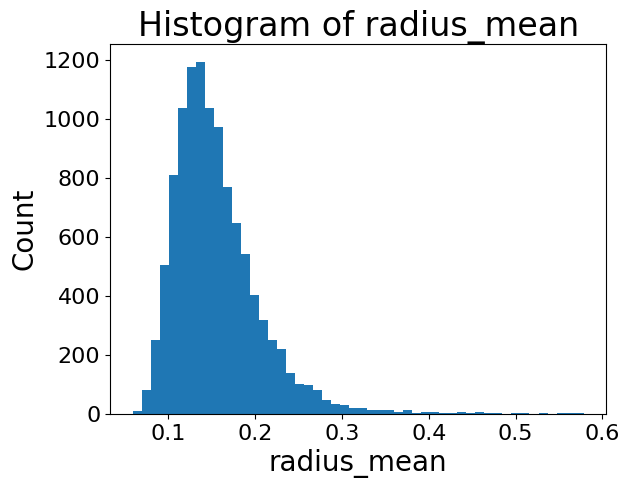

In [9]:
# Plot histogram of our chosen uncertainty measure: radius_mean
MEASURE = "radius_mean"
print(np.percentile(prediction_ensemble_measures[MEASURE], 0), 
      np.percentile(prediction_ensemble_measures[MEASURE], 25), 
      np.percentile(prediction_ensemble_measures[MEASURE], 50), 
      np.percentile(prediction_ensemble_measures[MEASURE], 75), 
      np.percentile(prediction_ensemble_measures[MEASURE], 100))
plt.hist(prediction_ensemble_measures[MEASURE], bins=50)
plt.title(f'Histogram of {MEASURE}')
plt.xlabel(f'{MEASURE}')
plt.ylabel('Count');

In [10]:
# find a "low confidence threshold" and get the indices of the low confidence samples
PERCENTILE_THRESHOLD = 90
low_confidence_threshold = np.percentile(prediction_ensemble_measures['radius_mean'], PERCENTILE_THRESHOLD)
low_confidence_indices = prediction_ensemble_measures.index[prediction_ensemble_measures['radius_mean'] >= low_confidence_threshold].tolist()
print(low_confidence_threshold)
prediction_ensemble_measures["low_confidence"] = prediction_ensemble_measures['radius_mean'] >= low_confidence_threshold
prediction_ensemble_measures

0.21653349042245987


,file_id,chirp_idx,tightness,radius_mean,density,average_error_per_point,error_density,euclidean_distance,low_confidence
0,16693,4,0.847147,0.124818,4154.749008,0.700005,12539.822911,6.849045,False
1,16694,19,0.828258,0.141898,6366.653026,0.455482,3422.536846,3.596081,False
2,16694,18,0.815064,0.152687,3296.304017,0.452368,8323.832019,6.030863,False
3,16694,17,0.807424,0.157899,1161.313122,0.376690,4996.426173,2.629345,False
4,16694,16,0.848709,0.116488,3924.285426,0.491525,2844.829411,3.853025,False
...,...,...,...,...,...,...,...,...,...
10890,17524,6,0.790715,0.179353,964.657953,0.597299,879.600773,4.390521,False
10891,17524,5,0.803789,0.163408,1078.852402,0.467792,973.012240,4.195675,False
10892,17524,4,0.811168,0.156748,1343.797617,1.138794,1354.292057,8.883200,False
10893,17525,5,0.795300,0.175492,1309.445866,0.653897,908.119279,4.598601,False


In [11]:
unscaled_ground_truth = unscale(ground_truth, scaler_path, cols_to_keep=["file_id", "chirp_idx"])
unscaled_ground_truth

/home/ayc227/miniconda3/envs/bats310/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator QuantileTransformer from version 1.3.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


,TimeInFile,PrecedingIntrvl,HiFreq,Bndwdth,FreqMaxPwr,PrcntMaxAmpDur,FreqKnee,PrcntKneeDur,StartF,UpprKnFreq,...,Amp2ndQrtl,Amp3rdQrtl,Amp4thQrtl,1st10kHzSlp,1st5to15kHzSlp,1st10kHzExp,1st5to15kHzExp,AmpK@start,file_id,chirp_idx
0,1514.999990,86.000000,73.442747,27.074597,54.179102,54.729164,52.135644,64.509295,73.442747,60.484401,...,8769.741215,15616.055230,12429.542955,14.097721,9.354195,129.228862,106.436745,4.470350,16693.0,4.0
1,1848.999988,82.000000,85.892290,40.796518,51.132176,68.501612,65.281315,23.025752,85.892290,65.281315,...,14213.696222,20336.769621,7052.027650,23.177943,19.795116,166.116571,154.967097,13.441341,16694.0,19.0
2,1680.000025,83.000000,82.795382,39.384269,53.916698,55.368983,60.247496,32.149732,82.795382,66.894656,...,4357.833382,19896.553411,17251.677170,17.881734,21.593664,134.551667,159.316855,6.834603,16694.0,18.0
3,1596.999944,90.000000,83.515950,40.841733,55.067086,47.408007,61.631393,26.460283,83.515950,61.631393,...,18380.062892,11501.507768,13995.540981,17.204441,17.644916,130.237594,135.986491,4.906056,16694.0,17.0
4,1506.999984,79.000000,87.488464,46.045368,57.271147,43.938016,61.581652,30.463689,87.488464,61.581652,...,19015.930484,13637.774716,14611.093873,29.915348,23.788136,205.131836,178.565429,2.358377,16694.0,16.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10890,806.000000,91.000000,74.486998,32.537391,50.152151,67.806487,62.877837,13.201264,74.486998,62.877837,...,8099.409188,26311.835662,15246.375774,22.966967,14.975151,189.795722,141.420461,16.286443,17524.0,6.0
10891,623.000003,150.000009,83.086126,34.500439,51.994224,75.810369,62.330865,29.273311,83.086126,62.330865,...,13812.827351,16394.712479,19052.529750,21.347103,22.956145,173.449743,197.232036,23.078935,17524.0,5.0
10892,471.999999,81.000000,98.702430,59.480846,68.290641,23.990602,60.327817,34.653090,98.702430,80.682963,...,3454.551366,13270.122446,5202.451716,29.330093,32.806686,196.944732,226.953224,0.946632,17524.0,4.0
10893,1765.000024,81.000000,88.939900,46.488759,51.058477,67.168655,64.728423,24.079329,88.939900,64.728423,...,14801.560687,26038.193814,13437.789555,31.175311,28.235738,220.438662,213.489013,14.266839,17525.0,5.0


Verify a sample of the dataframes generated thus far:

/home/ayc227/bats/src/andrew/analysis_utils.py:261: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize="small", framealpha=0.5)


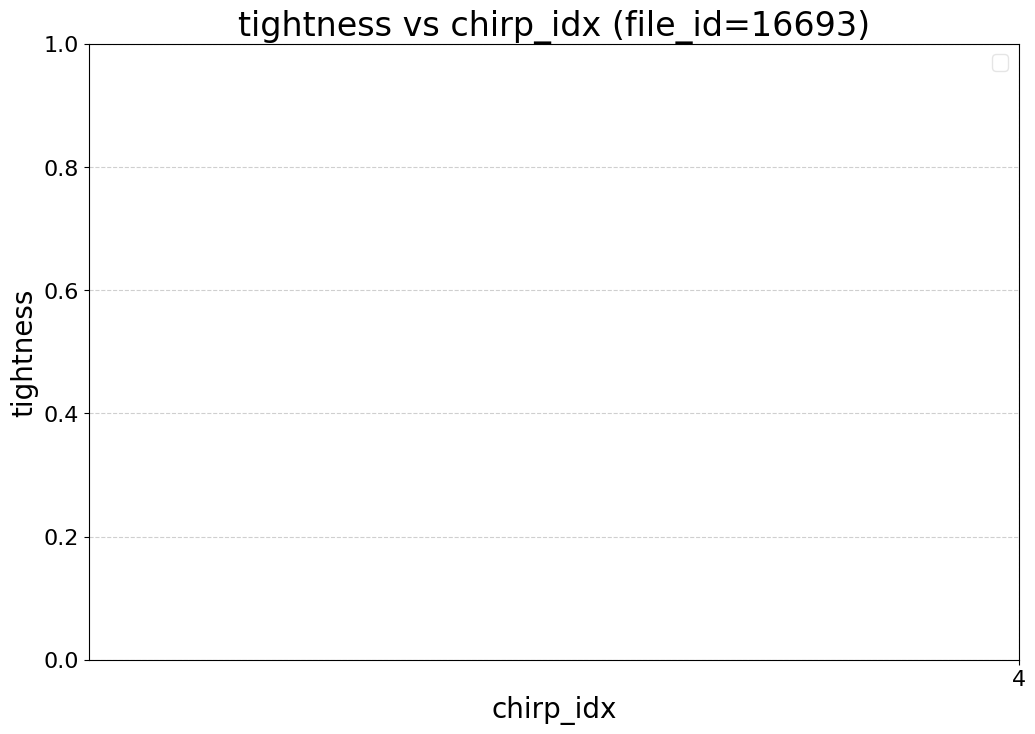

In [12]:
# Example uncertainty plot:
plot_uncertainty_by_file(min_file_id, prediction_ensemble_measures);

In [13]:
# # Plot each sequence of chirps for the test set
# test_range = range(min_file_id, max_file_id)
# save_folder = "../../bats_transformer/plots/july_daytime_new_mask_11_5"
# if not os.path.exists(save_folder):
#     os.mkdir(save_folder)
# for fid in tqdm(test_range):
#     try:
#         plot_uncertainty_by_file(fid, df=prediction_ensemble_measures, show=False, save_filename=f"{save_folder}/cluster_plot_{int(fid)}")
#     except ValueError as e:
#         print(e)

This section performs peak detection on the uncertainty sequences generated in the previous section.

In [14]:
# Peak detection courtesy of Andreas
import sys
sys.path.append("..")
from peak_detection.data_series_analyzer import DataSeriesAnalyzer

In [15]:
# # Sample usage of DataSeriesAnalyzer
# # sel = prediction_ensemble_measures[prediction_ensemble_measures["file_id"] == sample_file_id].copy()
# data = prediction_ensemble_measures['radius_mean']
# data.index = np.arange(len(data))
# analyzer = DataSeriesAnalyzer(data)
# # Get a df with columns:
# # 'frame_number', 'prominence', 'plateau', 'smoothed_content_val', 'content_vals'
# peaks_info = analyzer.analyze(sigma=3)

# analyzer.print_statistics(data, title="Raw Data")
# analyzer.print_statistics(analyzer.get_smoothed_data(), title="Smoothed Data")
# # Create visualizations
# # Time series with optional interactive preview
# fig: plt.Figure = analyzer.plot_timeseries(
#         [data, 
#             pd.Series(analyzer.get_smoothed_data())
#         ],
#         labels=['raw data', 'smoothed'],
#         interactive=False
# )
# plt.show(block=False)

In [16]:
# Example usage of detect_uncertainty_peaks
detect_uncertainty_peaks(min_file_id, prediction_ensemble_measures, "radius_mean", sigma=0)

ipykernel_launcher.py(3426): 2026-02-23 16:07:39,206;INFO: Found 0 scenes


,frame_number,prominence,plateau,smoothed_content_val,content_vals


In [17]:
# Find which files have a large range by comparing each sequence's range with the total population of ranges
from scipy.stats import ttest_1samp
from scipy.ndimage import gaussian_filter
PREDICTION_OFFSET = 4
SIGMA = 1
MEASURE = "radius_mean"

uncertainty_ranges = []
uncertainty_ranges_smoothed = []
for file_id in tqdm(prediction_ensemble_measures['file_id'].unique()):
    sel = prediction_ensemble_measures[prediction_ensemble_measures['file_id'] == file_id]
    uncertainty_range = sel[MEASURE].max() - sel[MEASURE].min()
    uncertainty_ranges.append(uncertainty_range)
    smoothed = gaussian_filter(sel[MEASURE], sigma=SIGMA, order=0, mode='reflect')
    uncertainty_range_smoothed = smoothed.max() - smoothed.min()
    uncertainty_ranges_smoothed.append(uncertainty_range_smoothed)
# add a column in prediction_ensemble_measures for whether or not a ttest_1samp for each uncertainty_range is significantly larger than the sample
for file_id, uncertainty_range in zip(prediction_ensemble_measures['file_id'].unique(), uncertainty_ranges_smoothed):
    sel = prediction_ensemble_measures[prediction_ensemble_measures['file_id'] == file_id]
    ttest_res = ttest_1samp(uncertainty_ranges_smoothed, uncertainty_range, alternative='greater')
    prediction_ensemble_measures.loc[sel.index, 'large_range'] = not (ttest_res.pvalue < 0.5)

mean_smoothed_uncertainty_range = np.mean(uncertainty_ranges_smoothed)
print("mean_smoothed_uncertainty_range:", f"{mean_smoothed_uncertainty_range:e}")

100%|██████████| 833/833 [00:00<00:00, 3094.28it/s]


mean_smoothed_uncertainty_range: 7.377562e-02


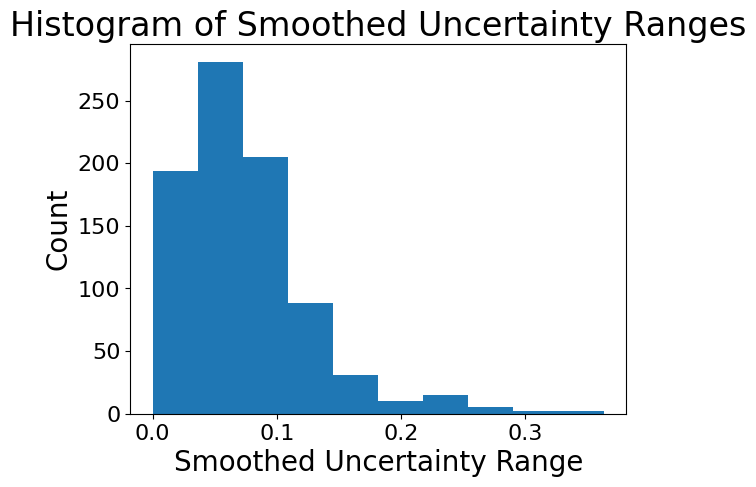

In [18]:
plt.hist(uncertainty_ranges_smoothed)
plt.title("Histogram of Smoothed Uncertainty Ranges")
plt.xlabel("Smoothed Uncertainty Range")
plt.ylabel("Count");

In [19]:
# recall that the measures are:
# tightness, radius_mean, density, average_error_per_point, error_density, euclidean_distance
MEASURE = "radius_mean"
peak_files = []
for file_id in tqdm(prediction_ensemble_measures['file_id'].unique()):
    peak_chirps = detect_uncertainty_peaks(file_id, prediction_ensemble_measures, MEASURE, sigma=SIGMA)
    if peak_chirps is not None and not peak_chirps.empty:
        # print(f"file_id={file_id} has peaks at chirp index: {(peak_chirps['frame_number'] + 4).tolist()}")
        for frame_number in peak_chirps['frame_number']:
            peak_files.append((file_id, frame_number + PREDICTION_OFFSET))

  0%|          | 0/833 [00:00<?, ?it/s]ipykernel_launcher.py(3426): 2026-02-23 16:07:40,359;INFO: Found 0 scenes
ipykernel_launcher.py(3426): 2026-02-23 16:07:40,362;INFO: Found 2 scenes
ipykernel_launcher.py(3426): 2026-02-23 16:07:40,365;INFO: Found 1 scenes
ipykernel_launcher.py(3426): 2026-02-23 16:07:40,368;INFO: Found 1 scenes
ipykernel_launcher.py(3426): 2026-02-23 16:07:40,370;INFO: Found 0 scenes
ipykernel_launcher.py(3426): 2026-02-23 16:07:40,372;INFO: Found 2 scenes
ipykernel_launcher.py(3426): 2026-02-23 16:07:40,375;INFO: Found 2 scenes
ipykernel_launcher.py(3426): 2026-02-23 16:07:40,377;INFO: Found 0 scenes
ipykernel_launcher.py(3426): 2026-02-23 16:07:40,380;INFO: Found 0 scenes
ipykernel_launcher.py(3426): 2026-02-23 16:07:40,382;INFO: Found 2 scenes
ipykernel_launcher.py(3426): 2026-02-23 16:07:40,384;INFO: Found 3 scenes
ipykernel_launcher.py(3426): 2026-02-23 16:07:40,387;INFO: Found 2 scenes
ipykernel_launcher.py(3426): 2026-02-23 16:07:40,389;INFO: Found 0 scenes

In [20]:
file_id = 16739


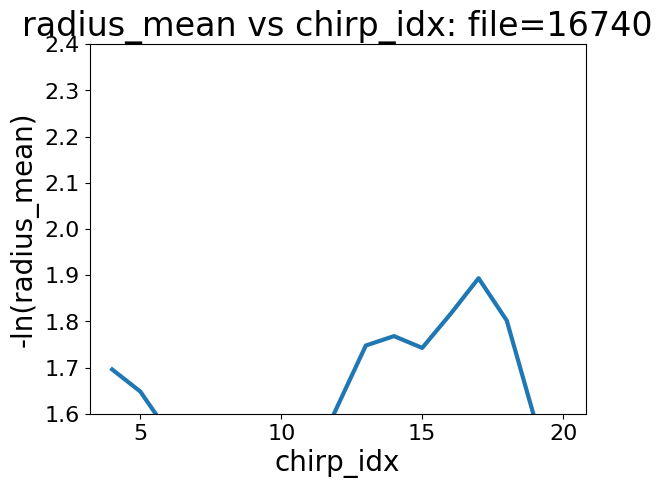

In [21]:
file_id+=1
plot_smoothed_uncertainty(file_id, prediction_ensemble_measures, MEASURE, sigma=SIGMA, ylim=(1.6, 2.4), show=True)

100%|██████████| 833/833 [00:00<00:00, 1314.01it/s]


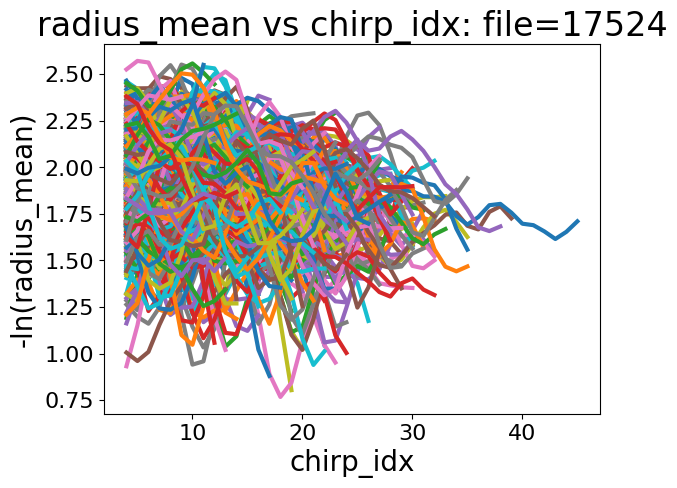

In [22]:
# FIGURE: 3.1 and 3.2

for file_id in tqdm(prediction_ensemble_measures['file_id'].unique()):
    if file_id in [fid for (fid, frame_number) in peak_files]:
        plot_smoothed_uncertainty(file_id, prediction_ensemble_measures, MEASURE, sigma=SIGMA, show=False)

In [23]:
# according to the (id, chirp_idx) pairs in peak_files, create a new column in prediction_ensemble_measures called "peak_detected" that is True for those pairs and False otherwise
prediction_ensemble_measures["peak_detected"] = 0
prev_file_id = 0
num_peaks = 1
for (file_id, chirp_idx) in peak_files:
    if file_id == prev_file_id:
        num_peaks += 1
    else:
        num_peaks = 1
    prediction_ensemble_measures.loc[(prediction_ensemble_measures['file_id'] == file_id) & 
                                     (prediction_ensemble_measures['chirp_idx'] == chirp_idx), 'peak_detected'] = num_peaks
    prev_file_id = file_id
prediction_ensemble_measures[prediction_ensemble_measures["peak_detected"] > 0].sort_values(['file_id', 'chirp_idx'])

,file_id,chirp_idx,tightness,radius_mean,density,average_error_per_point,error_density,euclidean_distance,low_confidence,large_range,peak_detected
11,16694,9,0.809240,0.155032,1216.501040,1.120420,933.357392,7.693159,False,False,1
2,16694,18,0.815064,0.152687,3296.304017,0.452368,8323.832019,6.030863,False,False,2
18,16695,15,0.767856,0.203333,532.315758,0.439770,286.304470,3.304225,False,False,1
34,16696,10,0.783875,0.183367,380.934215,0.858289,171.291976,7.018595,False,False,1
54,16698,7,0.797721,0.166034,436.025003,0.357186,302.226942,2.436598,False,False,1
...,...,...,...,...,...,...,...,...,...,...,...
10856,17521,9,0.845267,0.123913,6421.102164,0.382360,2937.945278,2.620013,False,False,1
10869,17522,7,0.805277,0.163451,775.918485,0.416042,17948.556261,5.883786,False,False,1
10877,17523,10,0.776461,0.192636,336.675793,0.533106,292.833448,3.756512,False,False,1
10874,17523,13,0.781625,0.186594,615.000650,0.292089,671.658921,2.148582,False,False,2


In [24]:
whole_idiom_metrics = prediction_ensemble_measures[prediction_ensemble_measures["peak_detected"] > 1]
whole_idiom_metrics

,file_id,chirp_idx,tightness,radius_mean,density,average_error_per_point,error_density,euclidean_distance,low_confidence,large_range,peak_detected
2,16694,18,0.815064,0.152687,3296.304017,0.452368,8323.832019,6.030863,False,False,2
49,16698,12,0.830825,0.143039,7830.834547,0.308428,546.054545,2.151012,False,False,2
62,16699,14,0.791122,0.174347,162.042647,0.620939,98.017322,4.240449,False,False,2
95,16702,15,0.834324,0.125922,1613.690903,0.390992,7939.309156,3.052800,False,False,2
111,16703,13,0.737399,0.244798,355.958370,0.425766,129.126536,3.221082,True,False,3
...,...,...,...,...,...,...,...,...,...,...,...
10697,17499,18,0.822839,0.147822,2181.198052,0.289613,2730.713543,2.356263,False,False,2
10807,17514,16,0.719605,0.260814,210.962801,0.748236,463.053646,6.093809,True,True,3
10812,17514,11,0.721214,0.252172,56.221051,0.850179,37.325557,7.449306,True,True,2
10824,17516,14,0.686346,0.294435,18.806480,0.693829,14.804025,4.658469,True,True,2


This section does some analysis about the results of peak detection:

In [25]:
# plot a histogram of chirp_idx for peak chirps (aka starting index of idioms)
peak_chirp_indices = [chirp_idx for (file_id, chirp_idx) in peak_files] # for all peak chirps
peak_chirp_indices = whole_idiom_metrics["chirp_idx"] # for just peak chirps at the beginning of a whole idiom
print("mean peak chirp index:", np.mean(peak_chirp_indices), "median peak chirp index:", np.median(peak_chirp_indices))

mean peak chirp index: 16.759112519809825 median peak chirp index: 16.0


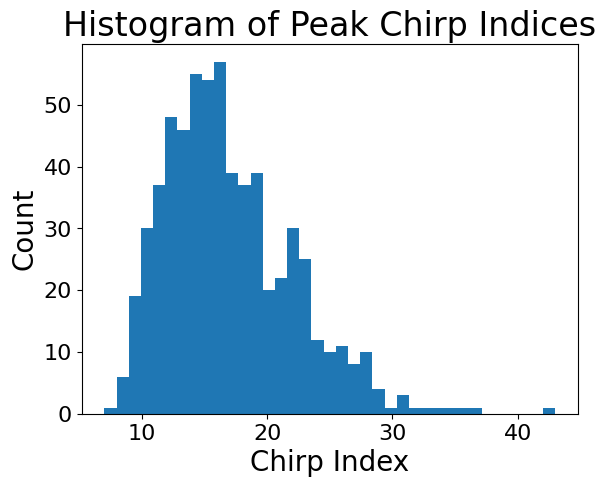

In [26]:
plt.hist(peak_chirp_indices, bins=(max(peak_chirp_indices) - min(peak_chirp_indices) + 1))
plt.title("Histogram of Peak Chirp Indices")
plt.xlabel("Chirp Index")
plt.ylabel("Count");

In [27]:
# for every row in prediction_ensemble_measures where peak_detected is True, calculate the distance in chirp_idx to the previous peak_detected True row with the same file_id
prediction_ensemble_measures['distance_to_prev_peak'] = np.nan
for file_id in prediction_ensemble_measures['file_id'].unique():
    sel = prediction_ensemble_measures[prediction_ensemble_measures['file_id'] == file_id].sort_values('chirp_idx')
    prev_peak_chirp_idx = None
    for idx, row in sel.iterrows():
        if row['peak_detected'] > 0:
            if prev_peak_chirp_idx is not None:
                distance = row['chirp_idx'] - prev_peak_chirp_idx
                prediction_ensemble_measures.loc[idx, 'distance_to_prev_peak'] = distance
            prev_peak_chirp_idx = row['chirp_idx']
prediction_ensemble_measures[prediction_ensemble_measures["peak_detected"] > 0]

,file_id,chirp_idx,tightness,radius_mean,density,average_error_per_point,error_density,euclidean_distance,low_confidence,large_range,peak_detected,distance_to_prev_peak
2,16694,18,0.815064,0.152687,3296.304017,0.452368,8323.832019,6.030863,False,False,2,9.0
11,16694,9,0.809240,0.155032,1216.501040,1.120420,933.357392,7.693159,False,False,1,NaN
18,16695,15,0.767856,0.203333,532.315758,0.439770,286.304470,3.304225,False,False,1,NaN
34,16696,10,0.783875,0.183367,380.934215,0.858289,171.291976,7.018595,False,False,1,NaN
49,16698,12,0.830825,0.143039,7830.834547,0.308428,546.054545,2.151012,False,False,2,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...
10856,17521,9,0.845267,0.123913,6421.102164,0.382360,2937.945278,2.620013,False,False,1,NaN
10869,17522,7,0.805277,0.163451,775.918485,0.416042,17948.556261,5.883786,False,False,1,NaN
10874,17523,13,0.781625,0.186594,615.000650,0.292089,671.658921,2.148582,False,False,2,3.0
10877,17523,10,0.776461,0.192636,336.675793,0.533106,292.833448,3.756512,False,False,1,NaN


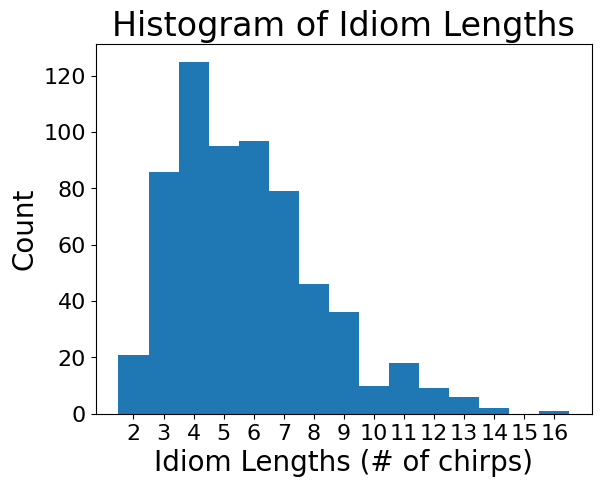

In [28]:
# FIGURE: 2.1

# plot a histogram of histogram lengths (distance from a peak to the previous peak, only if a previous peak exists)
# this only tracks whole idioms, as the distance from the beginning to the first peak is not measured
distance_values = prediction_ensemble_measures['distance_to_prev_peak'].dropna()
plt.hist(distance_values, bins=(np.arange(min(distance_values), max(distance_values) + 2) - 0.5))
# set the xticks to be integers from min to max distance
plt.xticks(np.arange(min(distance_values), max(distance_values) + 1))
plt.title("Histogram of Idiom Lengths")
plt.xlabel("Idiom Lengths (# of chirps)")
plt.ylabel("Count");

In [29]:
# extract the rows of prediction_ensemble_measures corresponding to files that have 2 or more peaks
# this corresponds to the sequences that contain one whole idiom

# this is not used for other parts of analysis
from collections import Counter
file_id_counts = Counter([file_id for (file_id, chirp_idx) in peak_files])
files_with_multiple_peaks = [file_id for file_id, count in file_id_counts.items() if count >= 2]
prediction_ensemble_measures_multiple_peaks = prediction_ensemble_measures[prediction_ensemble_measures['file_id'].isin(files_with_multiple_peaks)]
print("There are", len(files_with_multiple_peaks), "out of", len(file_id_counts), "files with 2+ peaks.")
prediction_ensemble_measures_multiple_peaks

There are 373 out of 625 files with 2+ peaks.


,file_id,chirp_idx,tightness,radius_mean,density,average_error_per_point,error_density,euclidean_distance,low_confidence,large_range,peak_detected,distance_to_prev_peak
1,16694,19,0.828258,0.141898,6366.653026,0.455482,3422.536846,3.596081,False,False,0,NaN
2,16694,18,0.815064,0.152687,3296.304017,0.452368,8323.832019,6.030863,False,False,2,9.0
3,16694,17,0.807424,0.157899,1161.313122,0.376690,4996.426173,2.629345,False,False,0,NaN
4,16694,16,0.848709,0.116488,3924.285426,0.491525,2844.829411,3.853025,False,False,0,NaN
5,16694,15,0.842158,0.123254,3733.868030,0.341984,3840.532242,2.601512,False,False,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
10879,17523,8,0.865578,0.100218,4581.030169,0.517757,8772.422917,4.249608,False,False,0,NaN
10880,17523,7,0.831573,0.136403,7584.553257,0.647910,8253.738272,6.629935,False,False,0,NaN
10881,17523,6,0.857576,0.112650,8116.581327,0.535906,10190.362250,5.358438,False,False,0,NaN
10882,17523,5,0.892098,0.082086,51419.025710,0.709370,73476.852535,5.584431,False,False,0,NaN


In [30]:
# from prediction_ensemble_measures, between every two peaks for the same file_id, extract the sequence of indices into a new array
# each sequence corresponds to one whole idiom
whole_idiom_sequences = []
for file_id in prediction_ensemble_measures['file_id'].unique():
    sequence = prediction_ensemble_measures[prediction_ensemble_measures['file_id'] == file_id]
    peak_indices = sequence[sequence['peak_detected'] > 0].index.tolist()
    # print(peak_indices)
    for i in range(len(peak_indices) - 1):
        start_idx = peak_indices[i]
        end_idx = peak_indices[i + 1]
        # unless it is the last peak, exclude the end_idx in the sequence
        if i < len(peak_indices) - 2:
            end_idx -= 1
        seq = sequence.loc[start_idx:end_idx]
        whole_idiom_sequences.append(seq.index.tolist())

print(len(whole_idiom_sequences))
whole_idiom_sequences

631


[[2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [49, 50, 51, 52, 53, 54],
 [62, 63, 64, 65, 66, 67, 68, 69, 70],
 [95, 96, 97, 98, 99],
 [111, 112, 113, 114, 115],
 [116, 117, 118],
 [123, 124, 125, 126, 127, 128, 129, 130],
 [165, 166, 167, 168, 169, 170, 171],
 [172, 173, 174, 175],
 [296, 297, 298, 299, 300, 301, 302, 303, 304, 305, 306, 307],
 [318, 319, 320, 321, 322, 323, 324],
 [356, 357, 358, 359, 360, 361, 362, 363, 364, 365, 366, 367],
 [379, 380, 381, 382],
 [404, 405, 406],
 [407, 408, 409, 410, 411, 412],
 [413, 414, 415, 416],
 [417, 418, 419, 420, 421, 422],
 [430, 431, 432, 433, 434],
 [435, 436, 437, 438],
 [446, 447, 448, 449, 450, 451, 452, 453, 454],
 [468, 469, 470],
 [471, 472, 473, 474, 475, 476],
 [486, 487, 488, 489],
 [490, 491, 492],
 [493, 494, 495, 496],
 [497, 498, 499, 500],
 [501, 502, 503, 504, 505],
 [568, 569],
 [570, 571, 572, 573, 574, 575, 576, 577],
 [583, 584, 585, 586],
 [612, 613, 614, 615, 616],
 [623, 624, 625, 626, 627, 628],
 [629, 630, 631, 632, 633],

In [31]:
# transform whole_idiom_sequences to be just the start and end chirp_idx values
whole_idiom_sequences_np = whole_idiom_sequences.copy()
for i in range(len(whole_idiom_sequences)):
    seq = whole_idiom_sequences[i]
    start_chirp_idx = seq[0]
    end_chirp_idx = seq[-1]
    whole_idiom_sequences_np[i] = (start_chirp_idx, end_chirp_idx)
# save the whole_idiom_sequences as a npy file
np.save("whole_idiom_sequences.npy", whole_idiom_sequences_np)
whole_idiom_sequences_np

[(2, 11),
 (49, 54),
 (62, 70),
 (95, 99),
 (111, 115),
 (116, 118),
 (123, 130),
 (165, 171),
 (172, 175),
 (296, 307),
 (318, 324),
 (356, 367),
 (379, 382),
 (404, 406),
 (407, 412),
 (413, 416),
 (417, 422),
 (430, 434),
 (435, 438),
 (446, 454),
 (468, 470),
 (471, 476),
 (486, 489),
 (490, 492),
 (493, 496),
 (497, 500),
 (501, 505),
 (568, 569),
 (570, 577),
 (583, 586),
 (612, 616),
 (623, 628),
 (629, 633),
 (640, 644),
 (656, 662),
 (669, 672),
 (673, 676),
 (677, 682),
 (717, 725),
 (737, 745),
 (755, 761),
 (762, 770),
 (796, 803),
 (813, 816),
 (817, 824),
 (873, 878),
 (887, 889),
 (890, 893),
 (894, 905),
 (917, 924),
 (925, 928),
 (937, 943),
 (944, 948),
 (980, 985),
 (986, 989),
 (1000, 1002),
 (1003, 1006),
 (1007, 1013),
 (1053, 1060),
 (1114, 1122),
 (1147, 1157),
 (1166, 1171),
 (1230, 1239),
 (1387, 1390),
 (1421, 1429),
 (1436, 1439),
 (1453, 1459),
 (1480, 1482),
 (1483, 1487),
 (1495, 1502),
 (1604, 1608),
 (1641, 1648),
 (1660, 1667),
 (1691, 1698),
 (1703, 1

In [32]:
# from prediction_ensemble_measures, extract the sequence of indices from the start to the first peak for each file_id that has a peak
# this is not used in analysis
onset_idiom_sequences = []
for file_id in prediction_ensemble_measures['file_id'].unique():
    sequence = prediction_ensemble_measures[prediction_ensemble_measures['file_id'] == file_id]
    peak_indices = sequence[sequence['peak_detected'] == True].index.tolist()
    # print(peak_indices)
    if len(peak_indices) == 0:
        continue
    start_idx = 0
    end_idx = peak_indices[0] - 1 # exclude the peak itself (it belongs to the next idiom)
    seq = sequence.loc[start_idx:end_idx]
    onset_idiom_sequences.append(seq.index.tolist())

# onset_idiom_sequences

In [33]:
# print the number of rows in prediction_ensemble_measures where peak_detected is True and large_range is True
print(prediction_ensemble_measures[(prediction_ensemble_measures['peak_detected'] == True) & (prediction_ensemble_measures['large_range'] == True)].shape[0], "chirps are peak and large range")
# print the number of rows in prediction_ensemble_measures where peak_detected is True
print(prediction_ensemble_measures[prediction_ensemble_measures['peak_detected'] == True].shape[0], "chirps are peak detected")
# print the number of rows in prediction_ensemble_measures where large_range is True
print(prediction_ensemble_measures[prediction_ensemble_measures['large_range'] == True].shape[0], "chirps are large range")
print("There are", prediction_ensemble_measures.shape[0], "total chirps")
prediction_ensemble_measures.sort_values(['peak_detected', 'large_range'], ascending=[False, False])

302 chirps are peak and large range
625 chirps are peak detected
6062 chirps are large range
There are 10895 total chirps


,file_id,chirp_idx,tightness,radius_mean,density,average_error_per_point,error_density,euclidean_distance,low_confidence,large_range,peak_detected,distance_to_prev_peak
6466,17167,43,0.753749,0.224377,477.086823,0.541374,593.156796,5.584863,True,True,6,8.0
7411,17227,34,0.723506,0.259414,190.558187,0.559472,551.895265,5.185526,True,True,6,7.0
486,16744,28,0.759039,0.205276,78.187747,0.708130,192.393567,6.848402,False,False,6,4.0
8670,17330,26,0.791182,0.177438,596.948657,0.799109,300.790890,7.083171,False,False,6,5.0
2562,16907,24,0.778993,0.193061,325.147663,0.537423,113.974046,4.207637,False,True,5,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...
10890,17524,6,0.790715,0.179353,964.657953,0.597299,879.600773,4.390521,False,False,0,NaN
10891,17524,5,0.803789,0.163408,1078.852402,0.467792,973.012240,4.195675,False,False,0,NaN
10892,17524,4,0.811168,0.156748,1343.797617,1.138794,1354.292057,8.883200,False,False,0,NaN
10893,17525,5,0.795300,0.175492,1309.445866,0.653897,908.119279,4.598601,False,False,0,NaN


In [34]:
# for each file_id where peak_detected is True, use split_filename_to_id_path to find each filename
filename_to_id_df = pd.read_csv(filename_to_id_path)
peak_filenames = []
for (file_id, chirp_idx) in peak_files:
    matching_rows = filename_to_id_df[filename_to_id_df['file_id'] == file_id]
    if not matching_rows.empty:
        filename = matching_rows.iloc[0]['Filename']
        # use unscaled_truth_list_0 to find the TimeInFile for this file_id and chirp_idx
        time_in_file = unscaled_ground_truth[(unscaled_ground_truth['chirp_idx'] == chirp_idx) & \
                                             (unscaled_ground_truth['file_id'] == file_id)]['TimeInFile'].iloc[0]
        peak_filenames.append((filename, file_id, chirp_idx, time_in_file))
peak_filenames

[('bats-20221007_023129_2secs.wav', 16694, 9, 824.9999988375858),
 ('bats-20221007_023129_2secs.wav', 16694, 18, 1680.0000248747988),
 ('bats-20221007_185022_2secs.wav', 16695, 15, 1875.0000001117273),
 ('bats-20221007_185024_2secs.wav', 16696, 10, 1074.999977883332),
 ('bats-20221007_190458_2secs.wav', 16698, 7, 769.0000007020548),
 ('bats-20221007_190458_2secs.wav', 16698, 12, 1176.0000005118306),
 ('bats-20221007_190536_2secs.wav', 16699, 6, 581.999996265001),
 ('bats-20221007_190536_2secs.wav', 16699, 14, 1405.0000114266127),
 ('bats-20221007_191417_2secs.wav', 16702, 11, 1166.000009223478),
 ('bats-20221007_191417_2secs.wav', 16702, 15, 1580.000031766173),
 ('bats-20221007_191419_2secs.wav', 16703, 6, 539.9999996687401),
 ('bats-20221007_191419_2secs.wav', 16703, 8, 897.9999989906219),
 ('bats-20221007_191419_2secs.wav', 16703, 13, 1428.999996852885),
 ('bats-20221007_194205_2secs.wav', 16704, 5, 420.0000156372586),
 ('bats-20221007_194205_2secs.wav', 16704, 12, 1343.9999816008071

In [35]:
# peak_indices = [(prediction_ensemble_measures.index[(prediction_ensemble_measures['file_id'] == file_id) & (prediction_ensemble_measures['chirp_idx'] == chirp_idx)][0]) for (file_id, chirp_idx) in peak_files]
peak_indices = [row[0] for row in whole_idiom_metrics.iterrows()]
print(len(peak_indices))
peak_indices

631


[2,
 49,
 62,
 95,
 111,
 116,
 123,
 165,
 172,
 296,
 318,
 356,
 379,
 404,
 407,
 413,
 417,
 430,
 435,
 446,
 468,
 471,
 486,
 490,
 493,
 497,
 501,
 568,
 570,
 583,
 612,
 623,
 629,
 640,
 656,
 669,
 673,
 677,
 717,
 737,
 755,
 762,
 796,
 813,
 817,
 873,
 887,
 890,
 894,
 917,
 925,
 937,
 944,
 980,
 986,
 1000,
 1003,
 1007,
 1053,
 1114,
 1147,
 1166,
 1230,
 1387,
 1421,
 1436,
 1453,
 1480,
 1483,
 1495,
 1604,
 1641,
 1660,
 1691,
 1703,
 1708,
 1712,
 1729,
 1760,
 1802,
 1829,
 1854,
 1861,
 1867,
 1883,
 1895,
 1904,
 1920,
 1924,
 1930,
 1938,
 1988,
 1994,
 2008,
 2013,
 2026,
 2042,
 2051,
 2054,
 2065,
 2076,
 2087,
 2129,
 2132,
 2179,
 2204,
 2210,
 2240,
 2261,
 2290,
 2319,
 2340,
 2354,
 2359,
 2365,
 2385,
 2426,
 2433,
 2460,
 2463,
 2477,
 2501,
 2511,
 2525,
 2528,
 2562,
 2564,
 2567,
 2574,
 2586,
 2600,
 2606,
 2611,
 2658,
 2701,
 2705,
 2719,
 2726,
 2733,
 2737,
 2742,
 2784,
 2800,
 2812,
 2846,
 2853,
 2889,
 2913,
 2930,
 2942,
 2947,
 29

This next section looks at the peak points to generate files corresponding to the peak contexts and peak chirps.
It will also organize the data into "idioms" based on the peak locations.
An idiom is defined as starting from the beginning of the file or from a peak chirp to the chirp before the next peak.

In [36]:
sys.path.append('../../bats_transformer/spacetimeformer')
import spacetimeformer as stf
# import spacetimeformer.spacetimeformer
import sys
sys.path.append('../../bats_transformer')
from data.bats_dataset import *
# from spacetimeformer.data.datamodule import DataModule
# print(sys.modules.keys())


ignore_cols = ["FreqLedge","AmpK@end", "Fc", "FBak15dB  ", "FBak32dB", "EndF", "FBak20dB", "LowFreq", "Bndw20dB", 
               "CallsPerSec", "EndSlope", "SteepestSlope", "StartSlope", "Bndw15dB", "HiFtoUpprKnSlp", "HiFtoKnSlope", 
               "DominantSlope", "Bndw5dB", "PreFc500", "PreFc1000", "PreFc3000", "KneeToFcSlope", "TotalSlope", 
               "PreFc250", "CallDuration", "CummNmlzdSlp", "DurOf32dB", "SlopeAtFc", "LdgToFcSlp", "DurOf20dB", "DurOf15dB", 
               "TimeFromMaxToFc", "KnToFcDur", "HiFtoFcExpAmp", "AmpKurtosis", "LowestSlope", "KnToFcDmp", "HiFtoKnExpAmp", 
               "DurOf5dB", "KnToFcExpAmp", "RelPwr3rdTo1st", "LnExpB_StartAmp", "Filter", "HiFtoKnDmp", "LnExpB_EndAmp", 
               "HiFtoFcDmp", "AmpSkew", "LedgeDuration", "KneeToFcResidue", "PreFc3000Residue", "AmpGausR2", "PreFc1000Residue", 
               "Amp1stMean", "LdgToFcExp", "FcMinusEndF", "Amp4thMean", "HiFtoUpprKnExp", "HiFtoKnExp", "KnToFcExp", "UpprKnToKnExp", 
               "Kn-FcCurviness", "Amp2ndMean", "Quality", "HiFtoFcExp", "LnExpA_EndAmp", "RelPwr2ndTo1st", "LnExpA_StartAmp", 
               "HiFminusStartF", "Amp3rdMean", "PreFc500Residue", "Kn-FcCurvinessTrndSlp", "PreFc250Residue", "AmpVariance", "AmpMoment", 
               "meanKn-FcCurviness", "MinAccpQuality", "AmpEndLn60ExpC", "AmpStartLn60ExpC", "Preemphasis", "MaxSegLnght" ,"Max#CallsConsidered" ]
ignore_cols += ["Filename", "NextDirUp", 'Path', 'Version', 'Filter', 'Preemphasis', 'MaxSegLnght', "ParentDir", "file_id", "chirp_idx", "split"]

data_module = stf.data.DataModule(
    datasetCls = BatsCSVDataset,
    dataset_kwargs = {
        "root_path": dataset_path,
        "prefix": "split",
        "ignore_cols": ignore_cols,
        "time_col_name": "TimeIndex",
        "val_split": 0.05,
        "test_split": 0.05,
        "context_points": None,
        "target_points": 1,
        "random_seed": 31
    },
    batch_size=64,
    workers=4,
)

test_data = data_module.test_dataloader()

/home/ayc227/miniconda3/envs/bats310/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/home/ayc227/miniconda3/envs/bats310/lib/python3.10/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(
/home/ayc227/miniconda3/envs/bats310/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator QuantileTransformer from version 1.3.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [37]:
import torch

low_conf_contexts = []
low_conf_truths = []

# Grab the contexts for the first chirp for each sequence, and 
# create a new dataframe extended from unscaled_ground_truth that includes chirp indices 0 through 3
contexts = []
batch_num = 0
for batch in tqdm(test_data):
    x_t, x_c, y_t, y_c = batch
    # if the idx of the data point is in one of [low_confidence_indices, peak_indices], save the context and truth
    batch_indices = np.array(range(x_c.shape[0])) + batch_num * data_module.batch_size
    for i, idx in enumerate(batch_indices):
        # if idx in low_confidence_indices:
        if idx in peak_indices:
            low_conf_contexts.append(x_c[i].cpu().numpy())
            low_conf_truths.append(y_c[i].cpu().numpy())
    batch_num += 1

    for i in range(x_c.shape[0]):
        # remove rows that only include 0s (padding)
        x_c_nonzero = x_c[i][~torch.all(x_c[i] == 0, dim=1)].detach().cpu().numpy()
        if (x_c_nonzero.shape[0] == 4):
            # print(x_c_nonzero.shape)
            contexts.append(x_c_nonzero)

contexts = np.asarray(contexts)

100%|██████████| 171/171 [00:57<00:00,  2.99it/s]


In [38]:
if dataset_path == "../../bats_transformer/data/2022_lake_2secs_myca/splits":
    column_names = unscaled_ground_truth.columns.tolist()
    contexts_df = pd.DataFrame(contexts.reshape(contexts.shape[0] * 4, -1), columns=column_names[:-2])
    contexts_df["file_id"] = [i for i in range(min_file_id, max_file_id) for _ in range(4)]
    contexts_df["chirp_idx"] = [i for i in range(4)] * (max_file_id - min_file_id)
    unscaled_contexts_df = unscale(contexts_df, scaler_path, cols_to_keep=[])
    unscaled_contexts_df["file_id"] = [i for i in range(min_file_id, max_file_id) for _ in range(4)]
    unscaled_contexts_df["chirp_idx"] = [i for i in range(4)] * (max_file_id - min_file_id)
else:
    column_names = unscaled_ground_truth.columns.tolist()
    contexts_df = pd.DataFrame(contexts.reshape(contexts.shape[0] * 4, -1), columns=column_names[:-2])
    contexts_df["file_id"] = [i for i in range(min_file_id, max_file_id + 1) for _ in range(4)]
    contexts_df["chirp_idx"] = [i for i in range(4)] * (max_file_id - min_file_id + 1)
    unscaled_contexts_df = unscale(contexts_df, scaler_path, cols_to_keep=[])
    unscaled_contexts_df["file_id"] = [i for i in range(min_file_id, max_file_id + 1) for _ in range(4)]
    unscaled_contexts_df["chirp_idx"] = [i for i in range(4)] * (max_file_id - min_file_id + 1)
unscaled_contexts_df

/home/ayc227/miniconda3/envs/bats310/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator QuantileTransformer from version 1.3.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


,TimeInFile,PrecedingIntrvl,HiFreq,Bndwdth,FreqMaxPwr,PrcntMaxAmpDur,FreqKnee,PrcntKneeDur,StartF,UpprKnFreq,...,Amp2ndQrtl,Amp3rdQrtl,Amp4thQrtl,1st10kHzSlp,1st5to15kHzSlp,1st10kHzExp,1st5to15kHzExp,AmpK@start,file_id,chirp_idx
0,948.999998,13.0,89.435630,44.806057,57.867189,60.032687,65.123930,36.019612,89.435630,65.123930,...,9758.684968,20388.213479,6470.118144,28.981507,29.331773,280.455573,309.487919,8.020989,16693,0
1,1270.000013,78.0,62.358614,11.356246,53.381204,72.431687,58.509973,26.225266,62.358614,58.509973,...,10124.521832,21962.453094,20755.313429,5.940938,5.532890,90.944058,90.514341,15.523974,16693,1
2,1345.999982,77.0,72.471536,22.256532,53.947669,72.623884,58.979873,35.735562,72.471536,58.979873,...,15056.701116,23075.011614,14938.604392,19.110792,14.831690,181.023653,156.595329,16.456111,16693,2
3,1428.999999,43.0,71.301819,19.488068,54.281644,79.966960,59.672125,45.981002,71.301819,59.672125,...,20985.109721,13561.578098,19490.040446,10.826228,7.477732,115.885699,99.530006,21.689882,16693,3
4,0.000000,0.0,59.619626,12.442710,51.627159,54.818029,49.353876,72.667451,59.619626,53.106793,...,20854.389327,23299.456384,5761.282359,5.435708,4.232091,60.349402,58.967684,9.956510,16694,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3327,391.000016,84.0,79.013424,34.499186,48.576133,80.353037,63.452734,20.541377,79.013424,63.452734,...,3452.190773,5939.217536,18653.469483,22.360041,17.886331,127.826080,118.194503,25.199262,17524,3
3328,746.000006,85.0,70.490400,25.963584,50.540939,71.373503,52.114113,57.535783,70.490400,52.114113,...,21102.578456,23720.540058,16165.055042,17.438977,8.325215,155.141289,100.546523,17.370270,17525,0
3329,1072.000010,89.0,71.308790,26.253723,48.878533,80.441742,50.790089,58.833465,71.308790,50.790089,...,20753.125856,14955.352426,19138.346219,19.168051,10.300429,174.760306,115.094279,27.616499,17525,1
3330,1249.999972,89.0,61.986667,14.070275,49.057143,83.222814,54.444813,35.279236,61.986667,54.444813,...,16039.194046,17485.287683,20085.575225,6.884549,4.248916,88.196524,75.221378,34.781368,17525,2


In [39]:
scaled_full_chirp_df = pd.concat([contexts_df, ground_truth], axis=0).sort_values(['file_id', 'chirp_idx'])
full_chirp_df = pd.concat([unscaled_contexts_df, unscaled_ground_truth], axis=0).sort_values(['file_id', 'chirp_idx'])
scaled_full_chirp_df

,TimeInFile,PrecedingIntrvl,HiFreq,Bndwdth,FreqMaxPwr,PrcntMaxAmpDur,FreqKnee,PrcntKneeDur,StartF,UpprKnFreq,...,1st10kHzSlp,1st5to15kHzSlp,1st10kHzExp,1st5to15kHzExp,AmpK@start,file_id,chirp_idx,Unnamed: 0,TimeIndex,model_id
0,0.136338,-1.705570,0.299929,0.350269,0.883035,-0.425024,0.654794,0.060432,0.306857,0.094689,...,0.624141,0.801789,1.080712,1.252566,-0.458611,16693.0,0.0,NaN,NaN,NaN
1,0.557182,0.253606,-1.451814,-1.894761,0.048584,0.317602,-0.519166,-0.767268,-1.456233,-0.767930,...,-1.568381,-1.334171,-1.367762,-1.127589,0.213598,16693.0,1.0,NaN,NaN,NaN
2,0.655343,0.193143,-0.659362,-0.957316,0.178254,0.329277,-0.455645,0.041083,-0.668940,-0.708790,...,-0.317648,-0.416620,0.060343,-0.179759,0.281849,16693.0,2.0,NaN,NaN,NaN
3,0.772126,-0.933910,-0.762999,-1.163437,0.239718,0.903683,-0.359275,0.754203,-0.771179,-0.630872,...,-0.997817,-1.005365,-0.893995,-0.927817,0.632165,16693.0,3.0,NaN,NaN,NaN
0,0.896717,0.832006,-0.578147,-0.613285,0.223689,-0.695453,-1.385929,1.638830,-0.580797,-0.537741,...,-0.731106,-0.781688,-0.700437,-0.794223,-1.046507,16693.0,4.0,0.0,5.0,models/2022_barn_2secs_myca_quantile_1_16/mode...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3329,0.297918,1.057485,-0.762674,-0.665783,-1.256932,0.953219,-1.598002,1.395867,-0.770435,-1.777652,...,-0.311390,-0.700782,-0.027713,-0.657741,0.977288,17525.0,1.0,NaN,NaN,NaN
3330,0.530037,1.057485,-1.487885,-1.655078,-1.214020,1.235229,-1.064180,0.003865,-1.484916,-1.307283,...,-1.421218,-1.643285,-1.431378,-1.601097,1.346166,17525.0,2.0,NaN,NaN,NaN
3331,0.772802,1.181921,-0.763383,-0.724157,-1.278244,1.854542,-1.044891,0.570346,-0.771780,-1.288946,...,-0.364855,-0.719463,-0.330409,-0.788962,1.700462,17525.0,3.0,NaN,NaN,NaN
10894,1.035790,0.607463,-0.504513,-0.361046,0.717629,-1.799968,-1.179727,0.618865,-0.514725,-1.431378,...,-0.176951,-0.388032,-0.246807,-0.428584,-0.967221,17525.0,4.0,10894.0,5.0,models/2022_barn_2secs_myca_quantile_1_16/mode...


In [40]:
low_conf_contexts = np.array(low_conf_contexts)
low_conf_truths = np.array(low_conf_truths)
np.save(f"{output_folder}/peak_contexts.npy", low_conf_contexts)
np.save(f"{output_folder}/peak_truths.npy", low_conf_truths)

In [41]:
low_conf_contexts.shape, low_conf_truths.shape

((631, 46, 32), (631, 1, 32))

In this section, I investigate potential patterns in the identified "low-confidence" predictions through clustering.

In [42]:
# get all the features that contain "Amp" in their name from unscaled_ground_truth
amp_features = [col for col in unscaled_ground_truth.columns if "Amp" in col]
amp_features

['PrcntMaxAmpDur',
 'HiFtoUpprKnAmp',
 'HiFtoKnAmp',
 'HiFtoFcAmp',
 'UpprKnToKnAmp',
 'KnToFcAmp',
 'LdgToFcAmp',
 'Amp1stQrtl',
 'Amp2ndQrtl',
 'Amp3rdQrtl',
 'Amp4thQrtl',
 'AmpK@start']

In [43]:
# use sklearn hdbscan to cluster all chirps found in unscaled_ground_truth
from sklearn import cluster
import umap

NO_AMP = 2 # set to 0 to keep all amp features, 1 to remove [Amp1stQrtl, Amp2ndQrtl, Amp3rdQrtl, Amp4thQrtl], 2 to remove all amp features

chirp_data = scaled_full_chirp_df.loc[:, 'PrecedingIntrvl':'AmpK@start'].to_numpy()

# remove columns that contain "Amp" in their name if NO_AMP is set
if NO_AMP == 1:
    amp_indices = [i - 1 for i, col in enumerate(full_chirp_df.columns) if col in ["Amp1stQrtl", "Amp2ndQrtl", "Amp3rdQrtl", "Amp4thQrtl"]]
    chirp_data = np.delete(chirp_data, amp_indices, axis=1)
elif NO_AMP == 2:
    amp_indices = [i - 1 for i, col in enumerate(full_chirp_df.columns) if "Amp" in col]
    chirp_data = np.delete(chirp_data, amp_indices, axis=1)

chirp_data_embedded = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42
).fit_transform(chirp_data)

/home/ayc227/miniconda3/envs/bats310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [44]:
chirp_data_embedded_df = pd.DataFrame(chirp_data_embedded, columns=['UMAP1', 'UMAP2'])
chirp_data_embedded_df

,UMAP1,UMAP2
0,-0.346496,-2.361505
1,1.439476,3.971568
2,1.688364,1.775004
3,2.425540,2.257675
4,1.365653,2.927376
...,...,...
14222,1.001587,3.562392
14223,1.204927,4.822789
14224,-2.189795,3.661006
14225,-1.916311,3.158061


In [45]:
# for each sequence in whole_idiom_sequences, use chirp_data_embedded_df to get the sequence of 2D UMAP points
whole_idiom_umap_sequences = []
for seq_indices in whole_idiom_sequences:
    seq_umap_points = chirp_data_embedded_df.iloc[seq_indices].to_numpy()
    whole_idiom_umap_sequences.append(seq_umap_points)
print(len(whole_idiom_umap_sequences))
whole_idiom_umap_sequences

631


[array([[ 1.6883639 ,  1.7750038 ],
        [ 2.4255397 ,  2.2576754 ],
        [ 1.3656527 ,  2.927376  ],
        [-4.9588175 , 11.882964  ],
        [ 1.7363615 , -3.6327918 ],
        [-1.5201671 ,  2.0136163 ],
        [-1.2108752 , -4.9789896 ],
        [-3.3880153 ,  0.33383524],
        [-1.4772028 , -4.815581  ],
        [-3.3973932 ,  1.6169584 ]], dtype=float32),
 array([[-3.6423273,  1.912517 ],
        [-3.4873307,  0.5835128],
        [-3.3899593,  2.537953 ],
        [-2.0234008,  4.779882 ],
        [-2.20681  ,  4.4392858],
        [-1.6865215,  4.7652626]], dtype=float32),
 array([[ 1.7974286, -3.1035938],
        [ 0.2696078, -4.1620817],
        [ 1.0053601, -1.9353534],
        [-5.069444 , 11.893477 ],
        [ 0.7044134,  3.3481305],
        [ 1.3543674,  5.212162 ],
        [ 1.492491 ,  5.141895 ],
        [-1.7719378,  3.7539191],
        [-2.0970244,  1.7492875]], dtype=float32),
 array([[-2.271753  ,  4.2811995 ],
        [ 0.22253902,  1.392117  ],
       

First, we want to see how many clusters there should be.

/home/ayc227/miniconda3/envs/bats310/lib/python3.10/site-packages/scipy/_lib/_util.py:440: UserWarning: One of the clusters is empty. Re-run kmeans with a different initialization.
  return fun(*args, **kwargs)


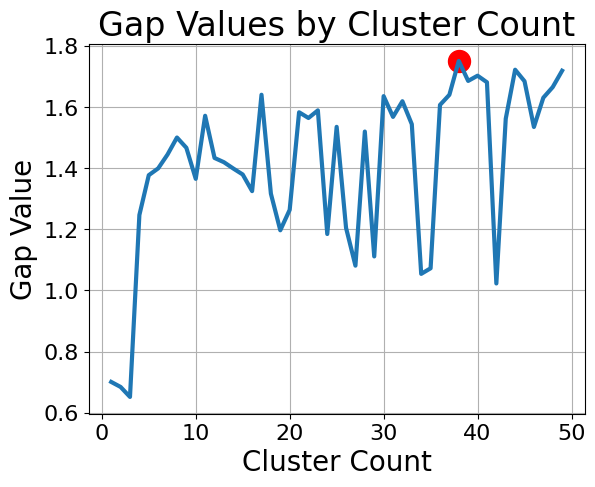

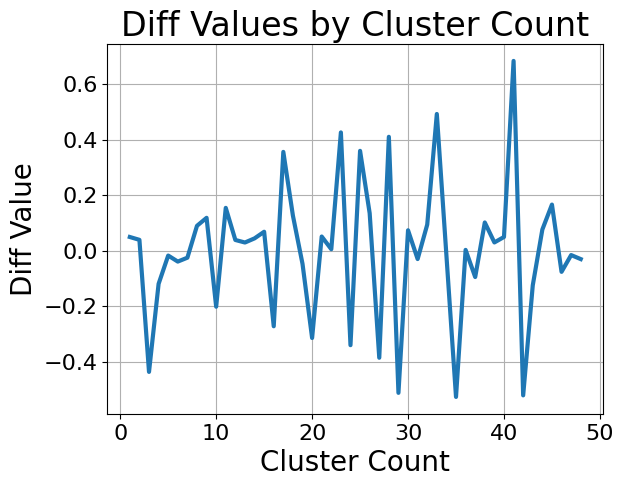

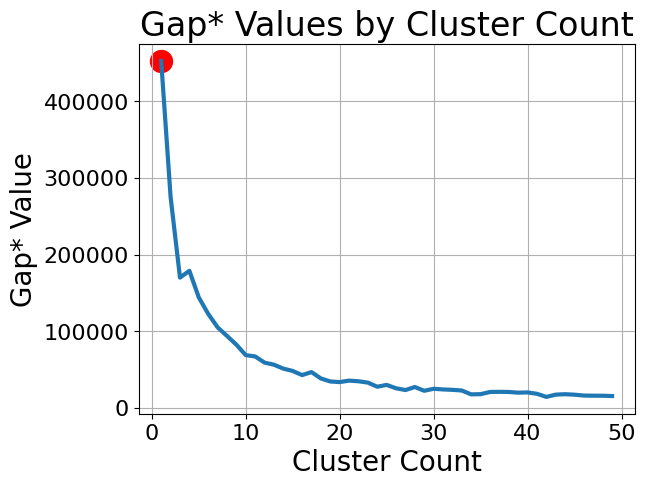

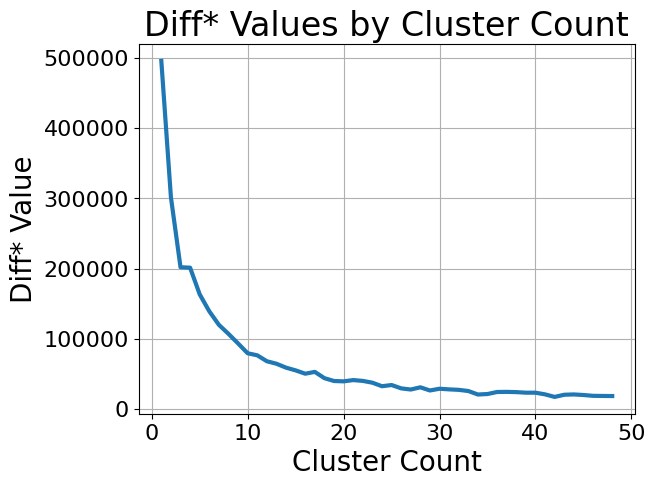

100%|██████████| 49/49 [03:01<00:00,  3.71s/it]


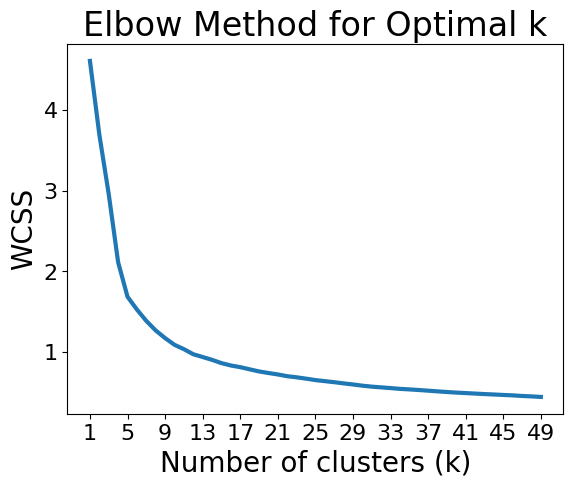

{'gap_statistic': 38, 'diff_statistic': 1, 'elbow_method': 9}

In [46]:
# FIGURE: 5.1

MIN_K = 1
MAX_K = 50

n_clusters = find_ideal_cluster_k(chirp_data_embedded, MIN_K, MAX_K, plot=True)
n_clusters

In [47]:
clustering = "Agglomerative"
umap = True
NUM_CLUSTERS = int(n_clusters["elbow_method"])

cluster_data_input = chirp_data_embedded if umap else chirp_data
chirp_labels = cluster_chirps(cluster_data_input, clustering, umap, NUM_CLUSTERS)

chirp_labels

array([3, 0, 0, ..., 6, 6, 1])

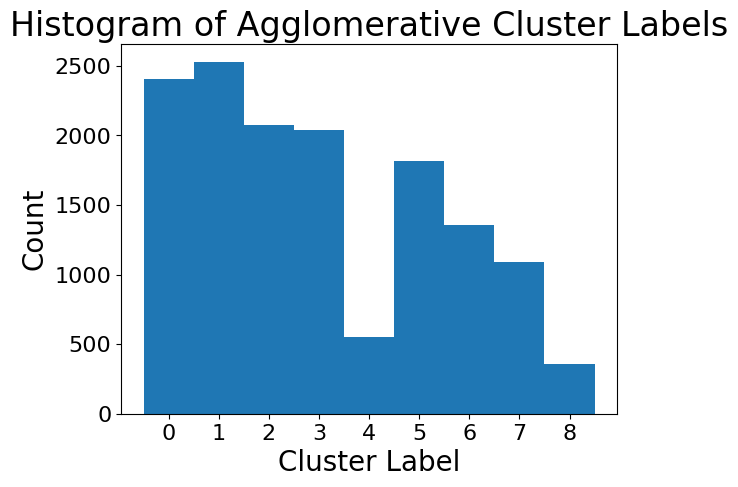

In [48]:
# FIGURE: 4.2

# plot histogram of chirp_labels
# set xticks to be integers from min to max chirp label
plt.xticks(np.arange(chirp_labels.min(), chirp_labels.max() + 1))
plt.hist(chirp_labels, bins=np.arange(chirp_labels.min(), chirp_labels.max() + 2) - 0.5)
plt.title(f"Histogram of {clustering} Cluster Labels")
plt.xlabel("Cluster Label")
plt.ylabel("Count");

In [49]:
pca = PCA(n_components=2)
chirp_data_2d = pca.fit_transform(chirp_data)
if umap:
    chirp_data_2d = chirp_data_embedded  # use UMAP embedding instead of PCA
# filter out noise points (label == -1)
filtered_chirp_data_2d = chirp_data_2d[chirp_labels != -1]
filtered_chirp_labels = chirp_labels[chirp_labels != -1]

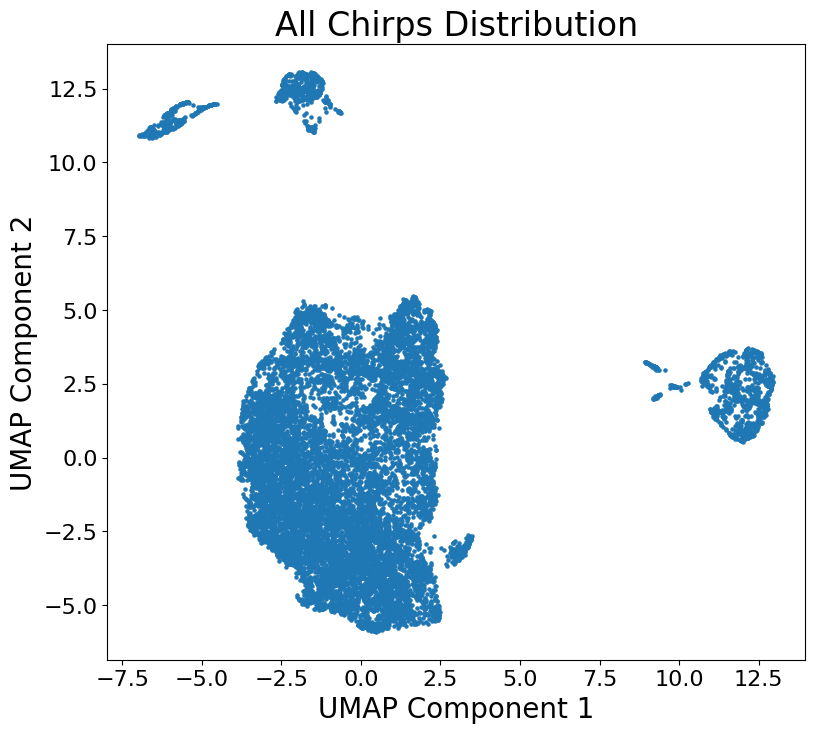

In [50]:
# FIGURE: 2.2
# for a baseline reference, just plot all the chirps as a scatterplot without clustering

colormap = "tab10" if NUM_CLUSTERS <= 10 else "tab20"
plt.figure(figsize=(9, 8))
scatter = plt.scatter(filtered_chirp_data_2d[:, 0], filtered_chirp_data_2d[:, 1], s=5)
plt.title(f"All Chirps Distribution")
# plt.colorbar(scatter, label="Cluster Label")
plt.xlabel(f"{'UMAP' if umap else 'PCA'} Component 1")
plt.ylabel(f"{'UMAP' if umap else 'PCA'} Component 2");
# if not umap:
#     plt.xlim(-8800, -8000);
#     plt.ylim(-1400, -1000);

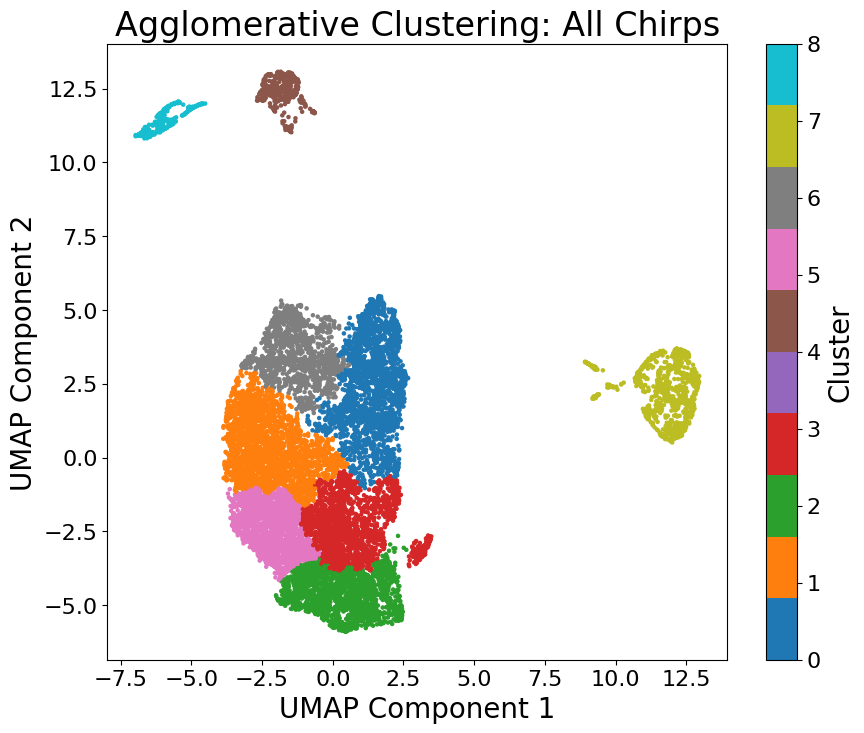

In [51]:
# FIGURE: 5.3
# plot the points in each cluster using PCA for dimensionality reduction

plt.figure(figsize=(10, 8))
scatter = plt.scatter(filtered_chirp_data_2d[:, 0], filtered_chirp_data_2d[:, 1], c=filtered_chirp_labels, cmap=colormap, s=5, 
                      vmin=min(chirp_labels), vmax=max(chirp_labels))
plt.title(f"{clustering} Clustering: All Chirps")# ({'UMAP' if umap else 'PCA'}-reduced to 2D)")
plt.colorbar(scatter, label="Cluster")
plt.xlabel(f"{'UMAP' if umap else 'PCA'} Component 1")
plt.ylabel(f"{'UMAP' if umap else 'PCA'} Component 2");
# if not umap:
#     plt.xlim(-8800, -8000);
#     plt.ylim(-1400, -1000);

In [52]:
# calculate the centroid of each cluster using the same colors but with a border
unique_labels = np.unique(filtered_chirp_labels)
centroids = []
for label in unique_labels:
    cluster_points = filtered_chirp_data_2d[filtered_chirp_labels == label]
    centroid = cluster_points.mean(axis=0)
    centroids.append(centroid)
centroids = np.array(centroids)

whole_idiom_sequence_clusters = []
# for each sequence in whole_idiom_umap_sequences, find the centroid of the cluster for each point in the sequence and plot a line connecting them
for seq_points in whole_idiom_umap_sequences:
    seq_labels = []
    for point in seq_points:
        # find the nearest point in filtered_chirp_data_2d to this point
        distances = np.linalg.norm(filtered_chirp_data_2d - point, axis=1)
        nearest_idx = np.argmin(distances)
        seq_labels.append(filtered_chirp_labels[nearest_idx])
    whole_idiom_sequence_clusters.append(seq_labels)

In [53]:
# # plot the paths using a naive matplotlib-native approach
# plt.figure(figsize=(10, 8))
# scatter = plt.scatter(filtered_chirp_data_2d[:, 0], filtered_chirp_data_2d[:, 1], c=filtered_chirp_labels, cmap=colormap, s=5, 
#                       vmin=min(chirp_labels), vmax=max(chirp_labels))
# plt.scatter(centroids[:, 0], centroids[:, 1], c=unique_labels, cmap=colormap, s=20, edgecolors="black", marker="X", label="Centroids")
# for seq_labels in whole_idiom_sequence_clusters:
#     seq_centroids = []
#     for label in seq_labels:
#         cluster_points = filtered_chirp_data_2d[filtered_chirp_labels == label]
#         centroid = cluster_points.mean(axis=0)
#         seq_centroids.append(centroid)
#     seq_centroids = np.array(seq_centroids)
#     # if 0 in seq_labels:
#     plt.plot(seq_centroids[:, 0], seq_centroids[:, 1], color="black", linewidth=1, alpha=0.5)

# plt.colorbar(scatter, label="Cluster")
# plt.xlabel(f"{'UMAP' if umap else 'PCA'} Component 1")
# plt.ylabel(f"{'UMAP' if umap else 'PCA'} Component 2");
# # if not umap:
# #     plt.xlim(-8800, -8000);
# #     plt.ylim(-1400, -1000);

In [54]:
# import networkx as nx

# G = nx.DiGraph()
# for seq in whole_idiom_sequence_clusters:
#     clusters = seq
#     for i in range(len(clusters)-1):
#         if G.has_edge(clusters[i], clusters[i+1]):
#             G[clusters[i]][clusters[i+1]]['weight'] += 1
#         else:
#             G.add_edge(clusters[i], clusters[i+1], weight=1)
# G.edges

In [55]:
# # plot the graph of all chirps in filtered_chirp_data_2d with paths according to whole_idiom_sequence_clusters with
# # edge weights according to G
# plt.figure(figsize=(10, 8))
# scatter = plt.scatter(filtered_chirp_data_2d[:, 0], filtered_chirp_data_2d[:, 1], c=filtered_chirp_labels, cmap=colormap, s=5, 
#                       vmin=min(chirp_labels), vmax=max(chirp_labels))
# pos = {node: centroids[i] for i, node in enumerate(unique_labels)}
# nx.draw_networkx_nodes(G, pos, node_size=300, node_color="lightblue")
# edges = G.edges()
# weights = [G[u][v]['weight'] for u,v in edges]
# nx.draw_networkx_edges(G, pos, edgelist=edges, width=[w * 0.2 for w in weights], alpha=0.7)
# nx.draw_networkx_labels(G, pos, font_size=10)
# plt.title("Cluster Transitions within Idioms")
# plt.xlabel(f"{'UMAP' if umap else 'PCA'} Component 1")
# plt.ylabel(f"{'UMAP' if umap else 'PCA'} Component 2")
# plt.show();

In [56]:
# # reproduce the plot but for every point that is in peak_indices, highlight it with a black star
# plt.figure(figsize=(10, 8))
# scatter = plt.scatter(filtered_chirp_data_2d[:, 0], filtered_chirp_data_2d[:, 1], c=filtered_chirp_labels, cmap=colormap, s=5,
#                       vmin=min(chirp_labels), vmax=max(chirp_labels))
# # overlay stars for peak_indices
# peak_chirp_clusters = chirp_labels[peak_indices]
# scatter_2 = plt.scatter(chirp_data_2d[peak_indices, 0], chirp_data_2d[peak_indices, 1], c=peak_chirp_clusters, 
#                         cmap=colormap, edgecolors="black", s=50, marker="*", vmin=min(chirp_labels), vmax=max(chirp_labels))
# plt.title(f"{clustering} Clusters of Chirps with Peak Indices Highlighted")# ({'UMAP' if umap else 'PCA'}-reduced to 2D)")
# plt.colorbar(scatter, label="Cluster Label")
# plt.xlabel(f"{'UMAP' if umap else 'PCA'} Component 1")
# plt.ylabel(f"{'UMAP' if umap else 'PCA'} Component 2")
# if not umap:
#     plt.xlim(-8800, -8000);
#     plt.ylim(-1400, -1000);

In [95]:
# FIGURES: 8.1 and 8.2

# find the most common 3-length label sequences in whole_idiom_sequence_clusters
N = 1
K_MOST_COMMON = 10
sequence_counts = most_common_subsequences(whole_idiom_sequence_clusters, N, k = K_MOST_COMMON, subseq_type="all")
prefix_counts = most_common_subsequences(whole_idiom_sequence_clusters, N, k = K_MOST_COMMON, subseq_type="prefix")
suffix_counts = most_common_subsequences(whole_idiom_sequence_clusters, N, k = K_MOST_COMMON, subseq_type="suffix")
subseqs = pd.DataFrame(sequence_counts, columns=['Subseq', 'Count'])
prefixs = pd.DataFrame(prefix_counts, columns=['Prefix', 'Count'])
suffixs = pd.DataFrame(suffix_counts, columns=['Suffix', 'Count'])

print(pd.concat([subseqs, prefixs, suffixs], axis=1))

  Subseq  Count Prefix  Count Suffix  Count
0   (1,)    701   (1,)    109   (3,)    108
1   (3,)    618   (3,)    105   (1,)    106
2   (0,)    574   (5,)     93   (2,)     93
3   (2,)    574   (0,)     90   (0,)     91
4   (5,)    554   (2,)     86   (5,)     87
5   (6,)    361   (6,)     50   (6,)     64
6   (7,)    348   (7,)     48   (7,)     47
7   (4,)    188   (4,)     29   (4,)     21
8   (8,)     85   (8,)     21   (8,)     14


In [58]:
# # plt.hist(peak_chirp_clusters, bins=np.arange(chirp_labels.min(), chirp_labels.max() + 2) - 0.5)
# plt.hist([chirp_labels, peak_chirp_clusters], density=True, bins=np.arange(chirp_labels.min(), chirp_labels.max() + 2) - 0.5)
# plt.legend(["All Chirps", "Peak Chrips"])
# plt.title(f"Histogram of {clustering} Cluster Labels for Peak Indices")
# plt.xlabel("Cluster Label")
# plt.ylabel("Count");

In [59]:
# This is perhaps a separate clustering method, but visualized using a dendrogram
from scipy.cluster.hierarchy import dendrogram, linkage

# plot dendrogram of agglomerative clustering
linked = linkage(chirp_data_embedded, 'ward')

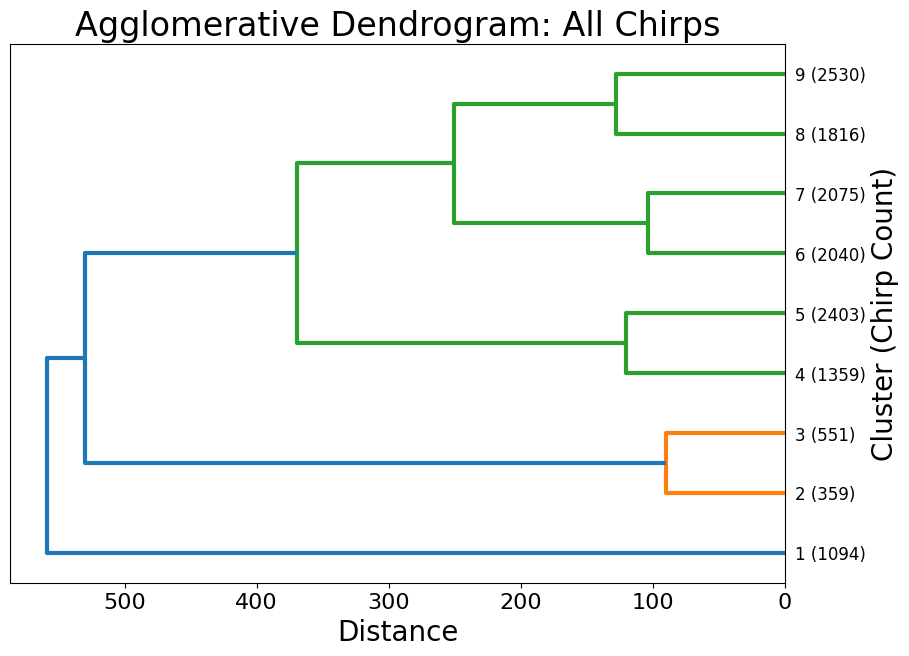

In [60]:
# FIGURE: 9.1

plt.figure(figsize=(10, 7))
chirp_dendrogram = dendrogram(linked,
           truncate_mode='lastp',
           p=NUM_CLUSTERS,
           orientation='left',
        #    distance_sort='descending',
           labels=chirp_labels,
           show_leaf_counts=True
           )

ax = plt.gca()
y_labels = ax.get_ymajorticklabels()
for i, y in enumerate(y_labels):
    y.set_text(f"{i+1} {y.get_text()}")
ax.set_yticklabels(y_labels)

plt.title('Agglomerative Dendrogram: All Chirps')
plt.xlabel('Distance')
ax.yaxis.set_label_position("right")
plt.ylabel('Cluster (Chirp Count)')
plt.show();

In [61]:
# Cut at specific height to get clusters
from scipy.cluster.hierarchy import fcluster
dendrogram_clusters = fcluster(linked, t=NUM_CLUSTERS, criterion='maxclust')  # get 10 clusters
dendrogram_clusters.shape

(14227,)

In [62]:
# value counts in clusters
pd.Series(dendrogram_clusters).value_counts()

9    2530
5    2403
7    2075
6    2040
8    1816
4    1359
1    1094
3     551
2     359
Name: count, dtype: int64

In [63]:
# value counts in clusters
pd.Series(chirp_labels).value_counts()

1    2530
0    2403
2    2075
3    2040
5    1816
6    1359
7    1094
4     551
8     359
Name: count, dtype: int64

In this section, I investigate which peak chirps (of low confidence) are *statistically* significant in terms of being a significant peak. The motivation behind this is that scipy's find_peaks doesn't consider any sort of statistical significance, just if there is a ^ shape in the plot.
Generally, this can be done by checking which chirps are >2sigmas over the mean uncertainty.
The challenge is how to get enough statistical power, specifically from sample size, as idiom sequences are only some 5-20 chirps long.
My approach checks the density (uncertainty) ranges of each idiom and groups similar ranges together in order to increase the sample size. But then there seems to be an issue of comparability, as it seems difficult to avoid weirdness comparing sequences with different ranges.

In [64]:
peak_df = prediction_ensemble_measures[prediction_ensemble_measures['peak_detected'] > 1][["file_id", "chirp_idx", MEASURE]].copy()
peak_df["surrounding_seq_idx"] = peak_df.index.map(lambda idx: get_surrounding_peak_sequence(idx, prediction_ensemble_measures, context_size=4))
peak_df["surrounding_seq_uncertainty"] = peak_df["surrounding_seq_idx"].map(
    lambda indices: prediction_ensemble_measures.loc[indices, MEASURE].values
)
peak_df["surround_seq_uncertainty_smoothed"] = peak_df["surrounding_seq_idx"].map(
    lambda indices: gaussian_filter(prediction_ensemble_measures.loc[indices, MEASURE].values, sigma=SIGMA, order=0, mode='reflect')
)
peak_df["seq_uncertainty_min"] = peak_df["surround_seq_uncertainty_smoothed"].map(lambda arr: arr.min())
peak_df["seq_uncertainty_max"] = peak_df["surround_seq_uncertainty_smoothed"].map(lambda arr: arr.max())
peak_df["seq_uncertainty_mean"] = peak_df["surround_seq_uncertainty_smoothed"].map(lambda arr: arr.mean())
peak_df["seq_uncertainty_range"] = peak_df["seq_uncertainty_max"] - peak_df["seq_uncertainty_min"]
# check if the seq_uncertainty_max occurs at the peak's index, i.e., the index of the row in peak_df
peak_df["peak_at_max"] = peak_df.apply(
    lambda row: row['surround_seq_uncertainty_smoothed'][row['surrounding_seq_idx'].index(row.name)] == row['seq_uncertainty_max'],
    axis=1
)
peak_df["normalized_surrounding_seq"] = peak_df["surround_seq_uncertainty_smoothed"].map(
    lambda arr: (arr - arr.mean())
)
peak_df.sort_values("seq_uncertainty_range")

,file_id,chirp_idx,radius_mean,surrounding_seq_idx,surrounding_seq_uncertainty,surround_seq_uncertainty_smoothed,seq_uncertainty_min,seq_uncertainty_max,seq_uncertainty_mean,seq_uncertainty_range,peak_at_max,normalized_surrounding_seq
2477,16899,10,0.133105,"[2481, 2480, 2479, 2478, 2477, 2476]","[0.12137835535007106, 0.11304597800142484, 0.1...","[0.11835127304301546, 0.11544519755754709, 0.1...",0.114362,0.121132,0.117686,0.006769,True,"[0.0006649580520055598, -0.002241117433462808,..."
2930,16931,13,0.131965,"[2934, 2933, 2932, 2931, 2930, 2929, 2928]","[0.14628752140558593, 0.12714080095958974, 0.1...","[0.1393678460687559, 0.13341476276150463, 0.13...",0.132947,0.140339,0.136947,0.007392,True,"[0.0024213027875525928, -0.003531780519698685,..."
6286,17153,20,0.161730,"[6290, 6289, 6288, 6287, 6286, 6285]","[0.1402653420044156, 0.16249671041665015, 0.12...","[0.14606276232837392, 0.14668319845535777, 0.1...",0.145106,0.152645,0.148099,0.007539,True,"[-0.0020358940915557455, -0.001415457964571903..."
9782,17426,8,0.171329,"[9786, 9785, 9784, 9783, 9782, 9781, 9780]","[0.13054591864942655, 0.14123763337000808, 0.1...","[0.13435028702031643, 0.136812080901524, 0.134...",0.134350,0.142339,0.136931,0.007989,True,"[-0.002580590930012977, -0.0001187970488054079..."
9274,17372,11,0.129180,"[9278, 9277, 9276, 9275, 9274, 9273, 9272]","[0.10659477486876756, 0.12458213165740631, 0.1...","[0.11208705976969197, 0.11454257123396255, 0.1...",0.107877,0.116308,0.112833,0.008431,True,"[-0.0007454465135375427, 0.001710064950733045,..."
...,...,...,...,...,...,...,...,...,...,...,...,...
4372,17028,20,0.507251,"[4376, 4375, 4374, 4373, 4372, 4371, 4370, 436...","[0.16744322532489206, 0.2164273615482995, 0.26...","[0.18854778184519383, 0.2204603202962089, 0.27...",0.165480,0.360605,0.253083,0.195125,True,"[-0.06453542972687792, -0.03262289127586285, 0..."
3356,16958,23,0.437059,"[3360, 3359, 3358, 3357, 3356, 3355]","[0.10339956384809605, 0.10925845254893662, 0.2...","[0.11158261583042867, 0.13785259399922994, 0.1...",0.111583,0.318382,0.222453,0.206799,True,"[-0.11087014500914485, -0.08460016684034358, -..."
1861,16858,22,0.440039,"[1865, 1864, 1863, 1862, 1861, 1860, 1859, 185...","[0.1295197525059431, 0.1266647687781542, 0.156...","[0.13084567521825144, 0.14276043855480364, 0.1...",0.130846,0.346540,0.242077,0.215694,True,"[-0.11123132299732849, -0.0993165596607763, -0..."
1930,16861,10,0.477700,"[1934, 1933, 1932, 1931, 1930, 1929, 1928, 192...","[0.18248442564197093, 0.14089142670044125, 0.1...","[0.16860702893506577, 0.16400154912846554, 0.2...",0.164002,0.390426,0.258089,0.226424,True,"[-0.08948180064137276, -0.09408728044797299, -..."


In [65]:
significant_peak_ids = []
for i in range(len(peak_df)):
    significant_peak_idxs = identify_significant_peaks(peak_df, i, 'normalized_surrounding_seq', "seq_uncertainty_range",
                                                             similarity_threshold=0.05,
                                                            #  std_threshold=2.0,
                                                             percentile_threshold=95,
                                                             verbose=0
                                                            )
    if len(significant_peak_idxs) > 0:
        significant_peak_ids.extend(significant_peak_idxs)
# remove duplicates
significant_peak_ids = list(set(significant_peak_ids))
significant_peak_ids

/home/ayc227/miniconda3/envs/bats310/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=9 observations were given.
  return hypotest_fun_in(*args, **kwds)
/home/ayc227/miniconda3/envs/bats310/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=12 observations were given.
  return hypotest_fun_in(*args, **kwds)
/home/ayc227/miniconda3/envs/bats310/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=18 observations were given.
  return hypotest_fun_in(*args, **kwds)
/home/ayc227/bats/src/andrew/analysis_utils.py:447: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  normalte

[3073,
 6658,
 8708,
 2054,
 2567,
 2568,
 8712,
 9224,
 10253,
 4623,
 6160,
 6672,
 8213,
 2583,
 3097,
 6683,
 2076,
 6173,
 4639,
 5667,
 3621,
 2600,
 4650,
 45,
 2606,
 4142,
 564,
 9782,
 8761,
 9274,
 3643,
 4668,
 10812,
 10811,
 8767,
 580,
 6724,
 1608,
 9801,
 5194,
 9800,
 10824,
 7246,
 6740,
 5719,
 4697,
 5213,
 8285,
 10335,
 6755,
 4709,
 2662,
 6245,
 5225,
 3695,
 625,
 4209,
 8305,
 7284,
 9332,
 10354,
 123,
 636,
 7804,
 8829,
 10877,
 8323,
 6278,
 6279,
 3208,
 6282,
 5260,
 2701,
 6286,
 10382,
 656,
 4241,
 9872,
 5779,
 9879,
 10392,
 665,
 7833,
 670,
 1695,
 165,
 7846,
 10407,
 1704,
 3242,
 6826,
 7339,
 8363,
 3758,
 4270,
 5296,
 2737,
 3250,
 10419,
 8888,
 9401,
 9402,
 1725,
 1726,
 4288,
 3777,
 10435,
 8389,
 5830,
 6858,
 7373,
 1230,
 6862,
 9935,
 8402,
 3283,
 4820,
 2261,
 10453,
 5849,
 10457,
 3803,
 7390,
 5855,
 4832,
 3297,
 4321,
 7391,
 10465,
 6889,
 9963,
 3308,
 4845,
 5358,
 7917,
 10480,
 5873,
 10479,
 6901,
 6902,
 4345,
 762,
 

In [66]:
# for each of the significant_peak_ids, add a column to prediction_ensemble_measures indicating it is a significant peak
prediction_ensemble_measures['significant_peak'] = prediction_ensemble_measures.index.isin(significant_peak_ids)
prediction_ensemble_measures

,file_id,chirp_idx,tightness,radius_mean,density,average_error_per_point,error_density,euclidean_distance,low_confidence,large_range,peak_detected,distance_to_prev_peak,significant_peak
0,16693,4,0.847147,0.124818,4154.749008,0.700005,12539.822911,6.849045,False,False,0,NaN,False
1,16694,19,0.828258,0.141898,6366.653026,0.455482,3422.536846,3.596081,False,False,0,NaN,False
2,16694,18,0.815064,0.152687,3296.304017,0.452368,8323.832019,6.030863,False,False,2,9.0,False
3,16694,17,0.807424,0.157899,1161.313122,0.376690,4996.426173,2.629345,False,False,0,NaN,False
4,16694,16,0.848709,0.116488,3924.285426,0.491525,2844.829411,3.853025,False,False,0,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10890,17524,6,0.790715,0.179353,964.657953,0.597299,879.600773,4.390521,False,False,0,NaN,False
10891,17524,5,0.803789,0.163408,1078.852402,0.467792,973.012240,4.195675,False,False,0,NaN,False
10892,17524,4,0.811168,0.156748,1343.797617,1.138794,1354.292057,8.883200,False,False,0,NaN,False
10893,17525,5,0.795300,0.175492,1309.445866,0.653897,908.119279,4.598601,False,False,0,NaN,False


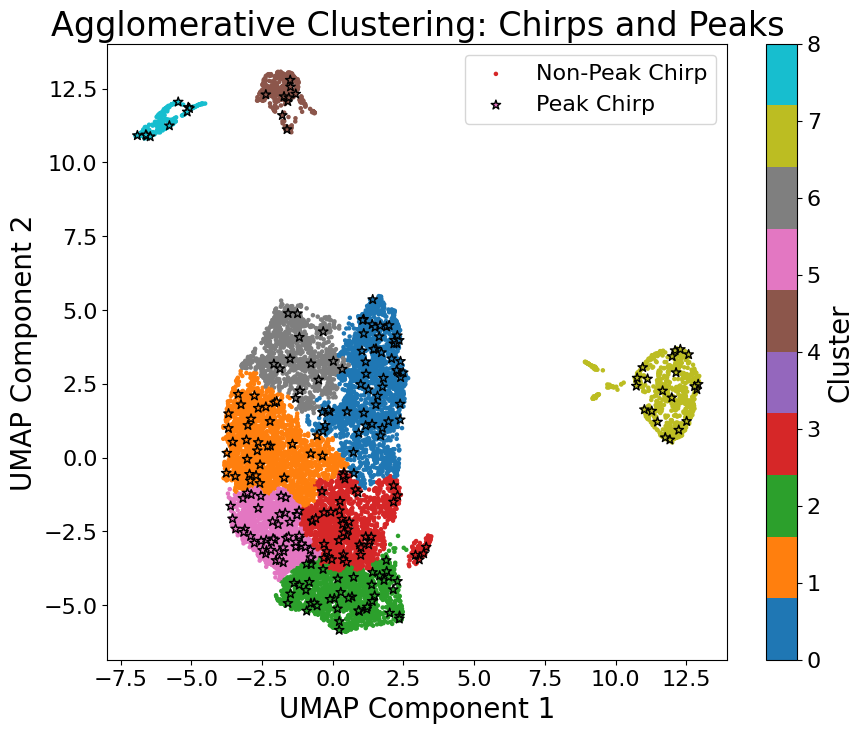

In [ ]:
# FIGURE: 6.2

# plot only the significant peaks on the previous scatter plot
plt.figure(figsize=(10, 8))
scatter = plt.scatter(filtered_chirp_data_2d[:, 0], filtered_chirp_data_2d[:, 1], c=filtered_chirp_labels, cmap=colormap, s=5,
                      vmin=min(chirp_labels), vmax=max(chirp_labels))
# overlay stars for peak_indices
significant_peak_chirp_clusters = chirp_labels[significant_peak_ids]
scatter_2 = plt.scatter(chirp_data_2d[significant_peak_ids, 0], chirp_data_2d[significant_peak_ids, 1], c=significant_peak_chirp_clusters, 
                        cmap=colormap, edgecolors="black", s=50, marker="*", vmin=min(chirp_labels), vmax=max(chirp_labels))
plt.title(f"{clustering} Clustering: Chirps and Peaks")# ({'UMAP' if umap else 'PCA'}-reduced to 2D)")
plt.colorbar(scatter, label="Cluster")
plt.xlabel(f"{'UMAP' if umap else 'PCA'} Component 1")
plt.ylabel(f"{'UMAP' if umap else 'PCA'} Component 2")
plt.legend(["Non-Peak Chirp", "Peak Chirp"])
if not umap:
    plt.xlim(-8800, -8000);
    plt.ylim(-1400, -1000);

In [68]:
prediction_ensemble_measures.iloc[2:12]

,file_id,chirp_idx,tightness,radius_mean,density,average_error_per_point,error_density,euclidean_distance,low_confidence,large_range,peak_detected,distance_to_prev_peak,significant_peak
2,16694,18,0.815064,0.152687,3296.304017,0.452368,8323.832019,6.030863,False,False,2,9.0,False
3,16694,17,0.807424,0.157899,1161.313122,0.376690,4996.426173,2.629345,False,False,0,NaN,False
4,16694,16,0.848709,0.116488,3924.285426,0.491525,2844.829411,3.853025,False,False,0,NaN,False
5,16694,15,0.842158,0.123254,3733.868030,0.341984,3840.532242,2.601512,False,False,0,NaN,False
6,16694,14,0.845843,0.121517,4661.820088,0.621782,3350.142475,4.476611,False,False,0,NaN,False
7,16694,13,0.852569,0.112228,5539.928222,0.651960,4668.989839,6.614695,False,False,0,NaN,False
8,16694,12,0.848238,0.121568,10744.500202,0.908349,8999.019652,6.659194,False,False,0,NaN,False
9,16694,11,0.840559,0.118415,1186.232567,0.706580,831.117524,6.746292,False,False,0,NaN,False
10,16694,10,0.789342,0.173480,737.909939,0.495163,634.904519,3.531487,False,False,0,NaN,False
11,16694,9,0.809240,0.155032,1216.501040,1.120420,933.357392,7.693159,False,False,1,NaN,False


In [69]:
significant_idiom_sequences = []
for file_id in prediction_ensemble_measures['file_id'].unique():
    sequence = prediction_ensemble_measures[prediction_ensemble_measures['file_id'] == file_id]
    peak_indices = sequence[sequence['peak_detected'] > 0].index.tolist()
    for i in range(len(peak_indices) - 1):
        start_idx = peak_indices[i]
        if prediction_ensemble_measures.loc[start_idx, "significant_peak"] == False:
            continue
        end_idx = peak_indices[i + 1]
        # unless it is the last peak, exclude the end_idx in the sequence
        if i < len(peak_indices) - 2:
            end_idx -= 1
        seq = sequence.loc[start_idx:end_idx]
        significant_idiom_sequences.append(seq.index.tolist())
print(len(significant_idiom_sequences))
significant_idiom_sequences

143


[[123, 124, 125, 126, 127, 128, 129, 130],
 [165, 166, 167, 168, 169, 170, 171],
 [413, 414, 415, 416],
 [417, 418, 419, 420, 421, 422],
 [490, 491, 492],
 [497, 498, 499, 500],
 [656, 657, 658, 659, 660, 661, 662],
 [762, 763, 764, 765, 766, 767, 768, 769, 770],
 [817, 818, 819, 820, 821, 822, 823, 824],
 [890, 891, 892, 893],
 [917, 918, 919, 920, 921, 922, 923, 924],
 [1230, 1231, 1232, 1233, 1234, 1235, 1236, 1237, 1238, 1239],
 [1421, 1422, 1423, 1424, 1425, 1426, 1427, 1428, 1429],
 [1829, 1830, 1831, 1832, 1833, 1834, 1835, 1836],
 [1904, 1905, 1906, 1907, 1908, 1909],
 [1924, 1925, 1926, 1927, 1928, 1929],
 [1930, 1931, 1932, 1933, 1934, 1935],
 [1988, 1989, 1990, 1991, 1992, 1993],
 [1994, 1995, 1996, 1997, 1998, 1999, 2000],
 [2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033],
 [2042, 2043, 2044, 2045, 2046, 2047, 2048, 2049, 2050],
 [2054, 2055, 2056, 2057, 2058, 2059],
 [2076, 2077, 2078, 2079, 2080, 2081, 2082, 2083, 2084, 2085, 2086],
 [2261, 2262, 2263, 2264, 2265, 2266, 2

In [70]:
import networkx as nx
# for each sequence in significant_idiom_sequences, use chirp_data_embedded_df to get the sequence of 2D UMAP points
significant_idiom_umap_sequences = []
for seq_indices in significant_idiom_sequences:
    seq_umap_points = chirp_data_embedded_df.iloc[seq_indices].to_numpy()
    significant_idiom_umap_sequences.append(seq_umap_points)

significant_idiom_sequence_clusters = []
# for each sequence in significant_idiom_umap_sequences, find the centroid of the cluster for each point in the sequence and plot a line connecting them
for seq_points in significant_idiom_umap_sequences:
    seq_labels = []
    for point in seq_points:
        # find the nearest point in filtered_chirp_data_2d to this point
        distances = np.linalg.norm(filtered_chirp_data_2d - point, axis=1)
        nearest_idx = np.argmin(distances)
        seq_labels.append(filtered_chirp_labels[nearest_idx])
    significant_idiom_sequence_clusters.append(seq_labels)

G = nx.DiGraph()
for seq in significant_idiom_sequence_clusters:
    clusters = seq
    for i in range(len(clusters)-1):
        if G.has_edge(clusters[i], clusters[i+1]):
            G[clusters[i]][clusters[i+1]]['weight'] += 1
        else:
            G.add_edge(clusters[i], clusters[i+1], weight=1)

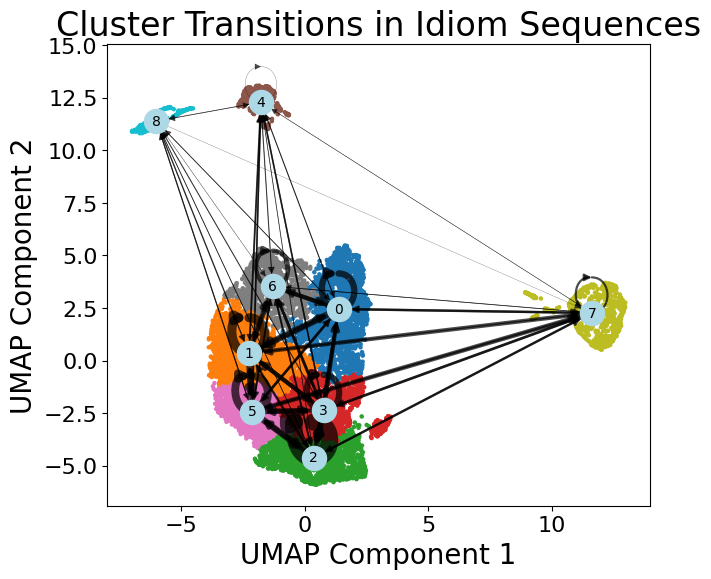

In [96]:
# FIGURE: 7.1

# plot the graph of all chirps in filtered_chirp_data_2d with paths according to significant_idiom_sequence_clusters with
# edge weights according to G
plt.figure(figsize=(7, 6))
scatter = plt.scatter(filtered_chirp_data_2d[:, 0], filtered_chirp_data_2d[:, 1], c=filtered_chirp_labels, cmap=colormap, s=5, 
                      vmin=min(chirp_labels), vmax=max(chirp_labels))
pos = {node: centroids[i] for i, node in enumerate(unique_labels)}
nx.draw_networkx_nodes(G, pos, node_size=300, node_color="lightblue", hide_ticks=False)
edges = G.edges()
weights = [G[u][v]['weight'] for u,v in edges]
nx.draw_networkx_edges(G, pos, edgelist=edges, width=[w * 0.2 for w in weights], alpha=0.7, hide_ticks=False)
nx.draw_networkx_labels(G, pos, font_size=10, hide_ticks=False)

# # draw xticks and yticks for the scatterplot
# plt.xticks(np.arange(int(filtered_chirp_data_2d[:, 0].min()), int(filtered_chirp_data_2d[:, 0].max()) + 1, 500))
# plt.yticks(np.arange(int(filtered_chirp_data_2d[:, 1].min()), int(filtered_chirp_data_2d[:, 1].max()) + 1, 500))


plt.title("Cluster Transitions in Idiom Sequences")
plt.xlabel(f"{'UMAP' if umap else 'PCA'} Component 1")
plt.ylabel(f"{'UMAP' if umap else 'PCA'} Component 2")
plt.show();

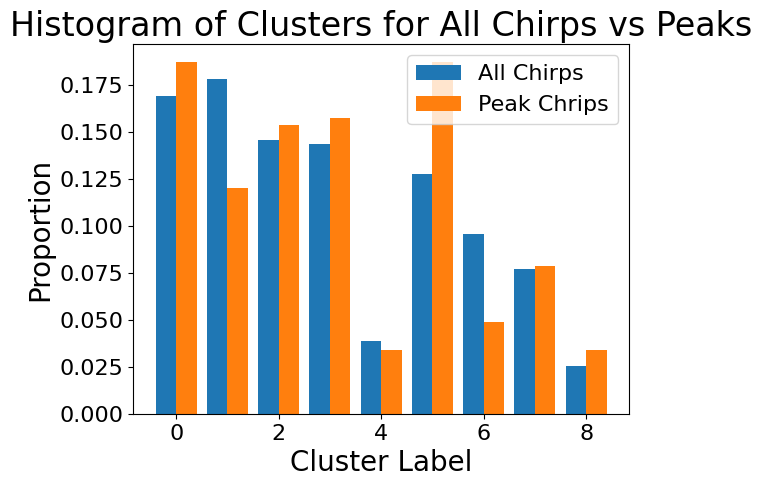

In [72]:
# plt.hist(peak_chirp_clusters, bins=np.arange(chirp_labels.min(), chirp_labels.max() + 2) - 0.5)
plt.hist([chirp_labels, chirp_labels[significant_peak_ids]], density=True, bins=np.arange(chirp_labels.min(), chirp_labels.max() + 2) - 0.5)
plt.legend(["All Chirps", "Peak Chrips"])
plt.title(f"Histogram of Clusters for All Chirps vs Peaks")
plt.xlabel("Cluster Label")
plt.ylabel("Proportion");

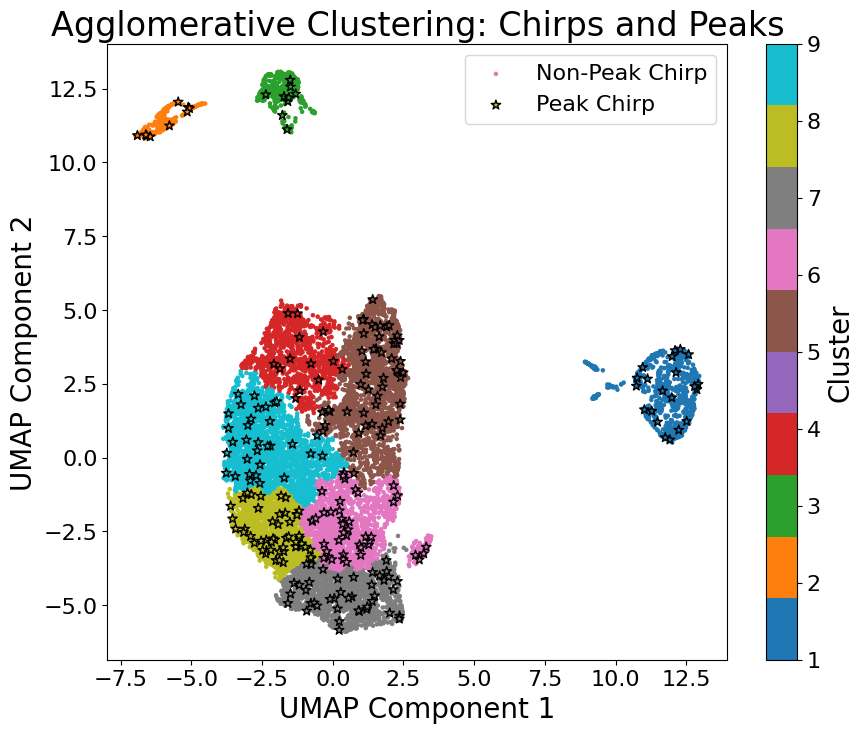

In [73]:
# FIGURE: 9.2

# do the above plotting but with the dendrogram clustering
plt.figure(figsize=(10, 8))
scatter = plt.scatter(filtered_chirp_data_2d[:, 0], filtered_chirp_data_2d[:, 1], c=dendrogram_clusters, cmap=colormap, s=5,
                      vmin=min(dendrogram_clusters), vmax=max(dendrogram_clusters))
# overlay stars for peak_indices
significant_peak_chirp_clusters = dendrogram_clusters[significant_peak_ids]
scatter_2 = plt.scatter(chirp_data_2d[significant_peak_ids, 0], chirp_data_2d[significant_peak_ids, 1], c=significant_peak_chirp_clusters, 
                        cmap=colormap, edgecolors="black", s=50, marker="*", vmin=min(dendrogram_clusters), vmax=max(dendrogram_clusters))
plt.title(f"{clustering} Clustering: Chirps and Peaks")# ({'UMAP' if umap else 'PCA'}-reduced to 2D)")
plt.colorbar(scatter, label="Cluster")
plt.xlabel(f"{'UMAP' if umap else 'PCA'} Component 1")
plt.ylabel(f"{'UMAP' if umap else 'PCA'} Component 2")
plt.legend(["Non-Peak Chirp", "Peak Chirp"])
if not umap:
    plt.xlim(-8800, -8000);
    plt.ylim(-1400, -1000);

Run the significance check on all chirp sequences

In [74]:
# first create a dataframe like peak_df but for all chirps in prediction_ensemble_measures
# each unique file_id is a row
all_chirps_df = prediction_ensemble_measures.reset_index().groupby('file_id').agg({'index': lambda x: x.tolist()})
# rename index to surrounding_seq_idx
all_chirps_df = all_chirps_df.rename(columns={'index': 'surrounding_seq_idx'})
all_chirps_df["surrounding_seq_uncertainty"] = all_chirps_df["surrounding_seq_idx"].map(
    lambda indices: prediction_ensemble_measures.loc[indices, MEASURE].values
)
all_chirps_df["surround_seq_uncertainty_smoothed"] = all_chirps_df["surrounding_seq_idx"].map(
    lambda indices: gaussian_filter(prediction_ensemble_measures.loc[indices, MEASURE].values, sigma=SIGMA, order=0, mode='reflect')
)
all_chirps_df["seq_uncertainty_min"] = all_chirps_df["surround_seq_uncertainty_smoothed"].map(lambda arr: arr.min())
all_chirps_df["seq_uncertainty_max"] = all_chirps_df["surround_seq_uncertainty_smoothed"].map(lambda arr: arr.max())
all_chirps_df["seq_uncertainty_mean"] = all_chirps_df["surround_seq_uncertainty_smoothed"].map(lambda arr: arr.mean())
all_chirps_df["seq_uncertainty_range"] = all_chirps_df["seq_uncertainty_max"] - all_chirps_df["seq_uncertainty_min"]
all_chirps_df["normalized_surrounding_seq"] = all_chirps_df["surround_seq_uncertainty_smoothed"].map(
    lambda arr: (arr - arr.mean())
)
all_chirps_df.sort_values("seq_uncertainty_range")
all_chirps_df

,surrounding_seq_idx,surrounding_seq_uncertainty,surround_seq_uncertainty_smoothed,seq_uncertainty_min,seq_uncertainty_max,seq_uncertainty_mean,seq_uncertainty_range,normalized_surrounding_seq
file_id,,,,,,,,
16693,[0],[0.12481762565996161],[0.12481762565996161],0.124818,0.124818,0.124818,0.000000,[0.0]
16694,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[0.1418982853334481, 0.15268706236706472, 0.15...","[0.14590763252031563, 0.14866668409746153, 0.1...",0.117967,0.153987,0.138019,0.036020,"[0.007888386293568722, 0.010647437870714621, 0..."
16695,"[17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 2...","[0.16129954936385477, 0.2033331702936981, 0.15...","[0.17319427001904808, 0.1745921540476137, 0.15...",0.131962,0.200789,0.158087,0.068827,"[0.01510717722192112, 0.01650506125048673, 0.0..."
16696,"[30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40]","[0.18897174628540514, 0.21800867212693326, 0.1...","[0.19489985355992795, 0.18890027794573544, 0.1...",0.139932,0.194900,0.171045,0.054968,"[0.023854378679471877, 0.017854803065279368, 0..."
16697,"[41, 42, 43, 44]","[0.12438623726365383, 0.10142904903115572, 0.1...","[0.11711082512339774, 0.11435493502618332, 0.1...",0.114355,0.139995,0.123811,0.025640,"[-0.006699966120230813, -0.009455856217445227,..."
...,...,...,...,...,...,...,...,...
17521,"[10853, 10854, 10855, 10856, 10857, 10858, 108...","[0.13559275557211567, 0.12510679003891473, 0.1...","[0.1322348718317928, 0.12993583330600106, 0.12...",0.098164,0.132235,0.118497,0.034071,"[0.013738258249531801, 0.011439219723740054, 0..."
17522,"[10862, 10863, 10864, 10865, 10866, 10867, 108...","[0.09839723888214134, 0.10748337691570738, 0.1...","[0.1015103935520066, 0.10447824462288496, 0.10...",0.101510,0.129370,0.112525,0.027860,"[-0.011014631015506746, -0.00804677994462838, ..."
17523,"[10873, 10874, 10875, 10876, 10877, 10878, 108...","[0.14177516019853342, 0.1865936653100431, 0.13...","[0.15456814795023077, 0.15861660680510245, 0.1...",0.092487,0.161734,0.133887,0.069247,"[0.020681242848273218, 0.024729701703144896, 0..."


In [75]:
all_chirps_significant_peaks = []
for i in range(len(all_chirps_df)):
    significant_peak_idxs = identify_significant_peaks(all_chirps_df, i, 'normalized_surrounding_seq', "seq_uncertainty_range",
                                                             similarity_threshold=0.05,
                                                            #  std_threshold=2.0,
                                                             percentile_threshold=95,
                                                             verbose=0
                                                            )
    if len(significant_peak_idxs) > 0:
            all_chirps_significant_peaks.extend(significant_peak_idxs)
# remove duplicates
all_chirps_significant_peaks = list(set(all_chirps_significant_peaks))
len(all_chirps_significant_peaks)

/home/ayc227/bats/src/andrew/analysis_utils.py:447: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  normaltest_result = normaltest(pooled_values)
/home/ayc227/miniconda3/envs/bats310/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=10 observations were given.
  return hypotest_fun_in(*args, **kwds)
/home/ayc227/miniconda3/envs/bats310/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=11 observations were given.
  return hypotest_fun_in(*args, **kwds)
/home/ayc227/miniconda3/envs/bats310/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=8 observations were given.
  

573

In this section, I investigate whether chirps within an idiom sequence are more similar with each other than with other chirps.

There are perhaps a few different ways to do this.
1. Find the volumn/density defined by an idiom sequence. Then pull a non-idiom sequence of the same length and find its volumn/density. Do this many times (using random samples) to produce two distributions, then run a statistical test to see if the idiom distribution mean is smaller.
2. Take a random sample of idioms. Do pairwise idiom-internal chirp comparison (something like cosine similarity) to generate a distribution of idiom-internal chirp similarity. Then randomly sample other chirps and do pairwise comparison between two chirps not in the same idiom to generate another distribution. Run a statistical test to see if the idiom-internal distribution mean is smaller.

In [76]:
# Example usage of calculate_sequence_volume
calculate_sequence_volume(get_attributes_from_indices(get_random_sequence(5, whole_idiom_sequences, unscaled_ground_truth), unscaled_ground_truth))

2.695161958078246e+119

In [77]:
whole_idiom_df = pd.DataFrame({"chirp_indices": whole_idiom_sequences})
whole_idiom_df["chirp_attributes"] = whole_idiom_df["chirp_indices"].map(
    lambda indices: get_attributes_from_indices(indices, unscaled_ground_truth)
)
whole_idiom_df["length"] = whole_idiom_df["chirp_indices"].map(lambda indices: len(indices))
whole_idiom_df

,chirp_indices,chirp_attributes,length
0,"[2, 3, 4, 5, 6, 7, 8, 9, 10, 11]","[[83.0, 82.79538208992082, 39.38426898122297, ...",10
1,"[49, 50, 51, 52, 53, 54]","[[81.0, 72.99217884542888, 33.67509597901926, ...",6
2,"[62, 63, 64, 65, 66, 67, 68, 69, 70]","[[63.0, 83.06297803081863, 39.5579589973131, 5...",9
3,"[95, 96, 97, 98, 99]","[[82.0, 92.22015919571362, 42.91661299748012, ...",5
4,"[111, 112, 113, 114, 115]","[[87.0, 61.92022410271735, 11.088618912493173,...",5
...,...,...,...
626,"[10697, 10698, 10699, 10700, 10701, 10702, 10703]","[[80.0, 89.02645217922557, 39.27539596940143, ...",7
627,"[10807, 10808, 10809, 10810, 10811]","[[70.0, 78.3762740395121, 29.788753922891377, ...",5
628,"[10812, 10813, 10814, 10815, 10816, 10817, 10818]","[[78.0, 95.74293087790315, 53.433293300904424,...",7
629,"[10824, 10825, 10826, 10827, 10828, 10829, 10830]","[[25.0, 96.23660125840104, 49.55319681827729, ...",7


In [78]:
# Approach 1: 
# get a distribution of idiom volumes by randomly sampling sequences of chirps
SAMPLE_SIZE = 1000
SEQ_LENGTH = 3
idiom_volumes = []
for _ in range(SAMPLE_SIZE):
    seq = get_random_idiom_sequence(SEQ_LENGTH, whole_idiom_df)
    attributes = get_attributes_from_indices(seq, unscaled_ground_truth)
    volume = calculate_sequence_volume(attributes)
    idiom_volumes.append(volume)
idiom_volumes = np.array(idiom_volumes)

# get a distribution of non-idiom volumes by randomly sampling sequences of chirps that do not overlap with idioms
non_idiom_volumes = []
for _ in range(SAMPLE_SIZE):
    seq = get_random_sequence(SEQ_LENGTH, whole_idiom_sequences, unscaled_ground_truth)
    attributes = get_attributes_from_indices(seq, unscaled_ground_truth)
    volume = calculate_sequence_volume(attributes)
    non_idiom_volumes.append(volume)
non_idiom_volumes = np.array(non_idiom_volumes)

if SAMPLE_SIZE < 20:
    print("Idiom volumes:", idiom_volumes)
    print("Non-idiom volumes:", non_idiom_volumes)

# scale down the volumes by 1e100 to avoid overflow in t-test
idiom_volumes /= 1e100
non_idiom_volumes /= 1e100

# take the log of the volumes (NOT STATISTICALLY EQUIVALENT TO SCALING)
# idiom_volumes = np.log(idiom_volumes + 1e-12)
# non_idiom_volumes = np.log(non_idiom_volumes + 1e-12)

if SAMPLE_SIZE < 20:
    print("Scaled idiom volumes:", idiom_volumes)
    print("Scaled non-idiom volumes:", non_idiom_volumes)

# run a statistical t-test to compare the two distributions
from scipy.stats import ttest_ind
t_stat, p_value = ttest_ind(idiom_volumes, non_idiom_volumes, equal_var=False, alternative='less')
print(f"Idiom volumes (scaled): mean = {np.mean(idiom_volumes):.4e}, std = {np.std(idiom_volumes):.4e}")
print(f"Non-idiom volumes (scaled): mean = {np.mean(non_idiom_volumes):.4e}, std = {np.std(non_idiom_volumes):.4e}")
print(f"T-test results: t-statistic = {t_stat:.4f}, p-value = {p_value:.4f}")

Idiom volumes (scaled): mean = 1.2107e+80, std = 3.3284e+81
Non-idiom volumes (scaled): mean = 5.6756e+109, std = 1.2678e+111
T-test results: t-statistic = -1.4149, p-value = 0.1958


/home/ayc227/miniconda3/envs/bats310/lib/python3.10/site-packages/scipy/stats/_stats_py.py:6173: RuntimeWarning: overflow encountered in scalar power
  df = (vn1 + vn2)**2 / (vn1**2 / (n1 - 1) + vn2**2 / (n2 - 1))


In [79]:
import scipy.spatial
# Approach 2:
# get a random sample of idiom sequences; within each sequence, calculate pairwise distances (euclidean) between chirps
SAMPLE_SIZE = 400
SEQ_LENGTH = 5
idiom_pairwise_distances = []
non_idiom_pairwise_distances = []
for _ in tqdm(range(SAMPLE_SIZE)):
    seq = get_random_idiom_sequence(SEQ_LENGTH, whole_idiom_df)
    attributes = get_attributes_from_indices(seq, unscaled_ground_truth)
    # pick a random chirp in attributes and calculate distances to all other chirps
    ref_idx = np.random.randint(0, len(attributes))
    ref_chirp = attributes[ref_idx]
    for i, chirp in enumerate(attributes):
        if i == ref_idx:
            continue
        dist = scipy.spatial.distance.euclidean(ref_chirp, chirp)
        idiom_pairwise_distances.append(dist)

    # pick SEQ_LENGTH - 1 random chirps not in the idiom sequence and calculate distances to the same ref_chirp
    non_idiom_indices = []
    for i in range(SEQ_LENGTH - 1):
        seq = get_random_sequence(1, whole_idiom_sequences, unscaled_ground_truth)
        non_idiom_indices.append(seq[0])

    non_idiom_attributes = get_attributes_from_indices(non_idiom_indices, unscaled_ground_truth)
    for chirp in non_idiom_attributes:
        dist = scipy.spatial.distance.euclidean(ref_chirp, chirp)
        non_idiom_pairwise_distances.append(dist)

idiom_pairwise_distances = np.array(idiom_pairwise_distances)
non_idiom_pairwise_distances = np.array(non_idiom_pairwise_distances)

if SAMPLE_SIZE <= 10:
    print("Idiom pairwise distances:", idiom_pairwise_distances)
    print("Non-idiom pairwise distances:", non_idiom_pairwise_distances)

# run a statistical t-test to compare the two distributions
t_stat, p_value = ttest_ind(idiom_pairwise_distances, non_idiom_pairwise_distances, equal_var=False, alternative='less')
print(f"Idiom pairwise distances: mean = {np.mean(idiom_pairwise_distances):.4e}, std = {np.std(idiom_pairwise_distances):.4e}")
print(f"Non-idiom pairwise distances: mean = {np.mean(non_idiom_pairwise_distances):.4e}, std = {np.std(non_idiom_pairwise_distances):.4e}")
print(f"T-test results: t-statistic = {t_stat:.4f}, p-value = {p_value:.4f}")

100%|██████████| 400/400 [00:01<00:00, 326.34it/s]


Idiom pairwise distances: mean = 1.8672e+04, std = 1.2326e+05
Non-idiom pairwise distances: mean = 6.3432e+04, std = 1.2156e+06
T-test results: t-statistic = -1.4649, p-value = 0.0716


In this section, I investigate potential patterns in the identified "low-confidence" predictions by looking at the SonoBat Cumulative SonoBatch file to see if there is a relationship between the confidence and the species

In [80]:
assert raw_audio_folder != None, "only proceed if raw_audio_folder is specified"

In [81]:
# get all .txt files with CumulativeSonoBatch in the name but not BatchSummary or NightlySummary
cumulative_sonobatch_files = [
    fn for fn in sorted(os.listdir(raw_audio_folder))
    if os.path.isfile(os.path.join(raw_audio_folder, fn)) and fn.endswith(".txt") and "CumulativeSonoBatch" in fn and "BatchSummary" not in fn and "NightlySummary" not in fn]
# read in the cumulative sono batch files into a single dataframe
cumulative_sonobatch_dfs = []
for fn in cumulative_sonobatch_files:
    df = pd.read_csv(os.path.join(raw_audio_folder, fn), sep=None, engine="python")
    cumulative_sonobatch_dfs.append(df)
cumulative_sonobatch_df = pd.concat(cumulative_sonobatch_dfs, ignore_index=True)
cumulative_sonobatch_df

,Path,Filename,HiF,LoF,SppAccp,Prob,#Maj,#Accp,~Spp,~Prob,...,4th,<--All spp in sqnc classified with a ANN>0.40 in order of prevalence,ParentDir,NextDirUp,FileLength(sec),Version,Filter,AccpQuality,AccpQualForTally,Max#CallsConsidered
0,Y:\batch4\chopped\20220213_2secs\bats-20220213...,bats-20220213_000424_2secs.wav,1.0,NaN,Myca/Myyu,0.48/0.52,1.0,3.0,NaN,NaN,...,NaN,NaN,20220213_2secs,chopped,2.0,30.2.20250912,5 kHz cutoff,0.6,unused,48
1,Y:\batch4\chopped\20220213_2secs\bats-20220213...,bats-20220213_000807_2secs.wav,1.0,NaN,Myca,0.9998,3.0,7.0,NaN,NaN,...,NaN,NaN,20220213_2secs,chopped,2.0,30.2.20250912,5 kHz cutoff,0.6,unused,48
2,Y:\batch4\chopped\20220213_2secs\bats-20220213...,bats-20220213_000854_2secs.wav,1.0,NaN,Myyu/Myca,0.59/0.41,3.0,6.0,NaN,NaN,...,NaN,NaN,20220213_2secs,chopped,2.0,30.2.20250912,5 kHz cutoff,0.6,unused,48
3,Y:\batch4\chopped\20220213_2secs\bats-20220213...,bats-20220213_001238_2secs.wav,1.0,1.0,Myca/Myyu,0.50/0.50,1.0,3.0,NaN,NaN,...,NaN,NaN,20220213_2secs,chopped,2.0,30.2.20250912,5 kHz cutoff,0.6,unused,48
4,Y:\batch4\chopped\20220213_2secs\bats-20220213...,bats-20220213_001240_2secs.wav,1.0,NaN,NaN,NaN/NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,20220213_2secs,chopped,2.0,30.2.20250912,5 kHz cutoff,0.6,unused,48
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64156,Y:\batch4\chopped\20221226_2secs\bats-20221226...,bats-20221226_204555_2secs.wav,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,20221226_2secs,chopped,1.5,30.2.20250912,5 kHz cutoff,0.0,unused,48
64157,Y:\batch4\chopped\20221226_2secs\bats-20221226...,bats-20221226_204718_2secs.wav,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,20221226_2secs,chopped,2.0,30.2.20250912,5 kHz cutoff,0.0,unused,48
64158,Y:\batch4\chopped\20221226_2secs\bats-20221226...,bats-20221226_204720_2secs.wav,NaN,1.0,Tabr,0.9972,2.0,2.0,NaN,NaN,...,NaN,NaN,20221226_2secs,chopped,1.0,30.2.20250912,5 kHz cutoff,0.6,unused,48
64159,Y:\batch4\chopped\20221226_2secs\bats-20221226...,bats-20221226_211905_2secs.wav,NaN,1.0,Tabr,0.9993,3.0,3.0,NaN,NaN,...,NaN,NaN,20221226_2secs,chopped,2.0,30.2.20250912,5 kHz cutoff,0.6,unused,48


In [82]:
# convert all Nan in SppAccp and Prob columns to string "NaN"
cumulative_sonobatch_df['SppAccp'] = cumulative_sonobatch_df['SppAccp'].fillna("NaN")
cumulative_sonobatch_df['Prob'] = cumulative_sonobatch_df['Prob'].fillna("NaN")

# adjust SppAccp and Prob to be the first element if it's a string with slashes
for i, val in enumerate(cumulative_sonobatch_df['SppAccp']):
    if isinstance(val, str) and '/' in val:
        cumulative_sonobatch_df.at[i, 'SppAccp'] = val.split('/')[0]
for i, val in enumerate(cumulative_sonobatch_df['Prob']):
    if isinstance(val, str) and '/' in val:
        cumulative_sonobatch_df.at[i, 'Prob'] = val.split('/')[0]

In [83]:
# using peak_filenames, find the corresponding rows in cumulative_sonobatch_df and extract relevant columns
peak_sonobatch_info = []
for (filename, file_id, chirp_idx, time_in_file) in peak_filenames:
    matching_rows = cumulative_sonobatch_df[cumulative_sonobatch_df['Filename'] == filename]
    if not matching_rows.empty:
        row = matching_rows.iloc[0]
        peak_sonobatch_info.append({
            "filename": filename,
            "file_id": file_id,
            "chirp_idx": chirp_idx,
            "time_in_file": time_in_file,
            "SppAccp": row.get("SppAccp", np.nan),
            "Prob": row.get("Prob", np.nan),
        })
peak_sonobatch_info_df = pd.DataFrame(peak_sonobatch_info)

# truncate prob to 2 decimal places
peak_sonobatch_info_df['Prob'] = peak_sonobatch_info_df['Prob'].astype(float).round(2)
peak_sonobatch_info_df

,filename,file_id,chirp_idx,time_in_file,SppAccp,Prob
0,bats-20221007_023129_2secs.wav,16694,9,824.999999,Myca,1.0
1,bats-20221007_023129_2secs.wav,16694,18,1680.000025,Myca,1.0
2,bats-20221007_185022_2secs.wav,16695,15,1875.000000,Myca,1.0
3,bats-20221007_185024_2secs.wav,16696,10,1074.999978,Myca,1.0
4,bats-20221007_190458_2secs.wav,16698,7,769.000001,Myca,1.0
...,...,...,...,...,...,...
1251,bats-20221104_185052_2secs.wav,17521,9,916.000000,Myca,1.0
1252,bats-20221104_185402_2secs.wav,17522,7,1103.000003,Myca,1.0
1253,bats-20221128_184228_2secs.wav,17523,10,1433.999976,Myca,1.0
1254,bats-20221128_184228_2secs.wav,17523,13,1818.999986,Myca,1.0


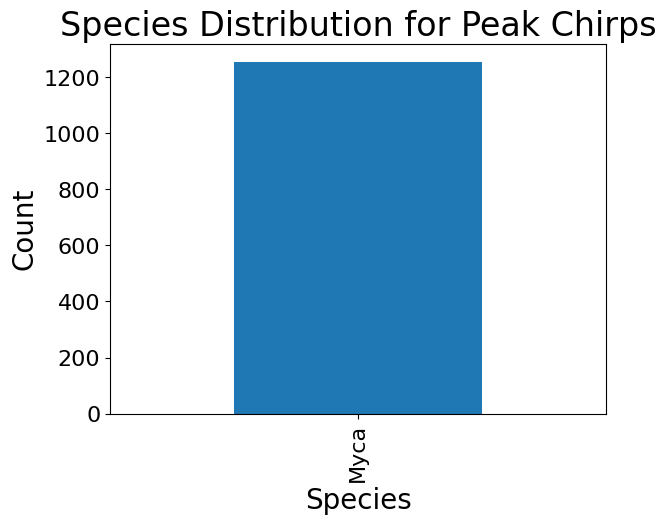

In [84]:
peak_sonobatch_info_df['SppAccp'].value_counts().plot.bar()
plt.title("Species Distribution for Peak Chirps")
plt.xlabel("Species")
plt.ylabel("Count");

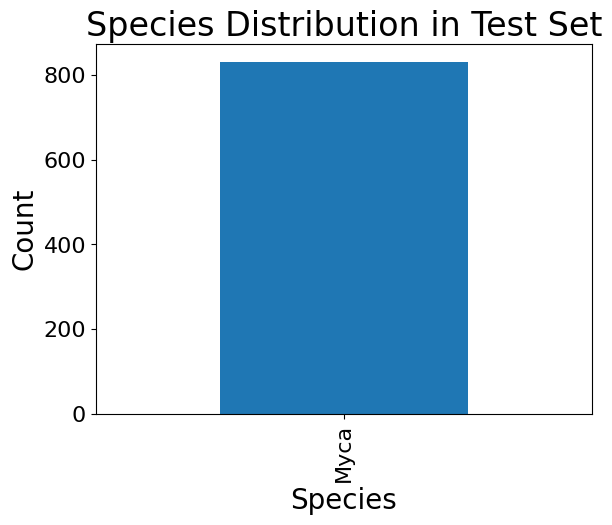

In [85]:
# use filename_to_id_path to find the filenames in the test set
test_range = range(int(min_file_id), int(max_file_id))
test_filenames = filename_to_id_df[filename_to_id_df['file_id'].isin(test_range)]['Filename'].tolist()
# filter cumulative_sonobatch_df to only those filenames
test_sonobatch_df = cumulative_sonobatch_df[cumulative_sonobatch_df['Filename'].isin(test_filenames)]
test_sonobatch_df['SppAccp'].value_counts().plot.bar()
plt.title("Species Distribution in Test Set")
plt.xlabel("Species")
plt.ylabel("Count");

In [86]:
# for each seq in significant_idiom_sequences, get the triple (file_id, start_chirp, end_chirp) from prediction_ensemble_measures
significant_idiom_triples = []
for seq in significant_idiom_sequences:
    file_id = prediction_ensemble_measures.loc[seq[0], 'file_id']
    end_id = prediction_ensemble_measures.loc[seq[0], 'chirp_idx']
    start_id = prediction_ensemble_measures.loc[seq[-1], 'chirp_idx']
    significant_idiom_triples.append((file_id, start_id, end_id))
print(len(significant_idiom_triples))
significant_idiom_triples

143


[(16704, 5, 12),
 (16711, 20, 26),
 (16739, 12, 15),
 (16739, 6, 11),
 (16744, 22, 24),
 (16744, 14, 17),
 (16755, 6, 12),
 (16761, 6, 14),
 (16765, 5, 12),
 (16772, 22, 25),
 (16773, 14, 21),
 (16800, 11, 20),
 (16819, 9, 17),
 (16856, 11, 18),
 (16860, 13, 18),
 (16861, 11, 16),
 (16861, 5, 10),
 (16867, 14, 19),
 (16867, 7, 13),
 (16869, 9, 16),
 (16870, 15, 23),
 (16870, 6, 11),
 (16872, 14, 24),
 (16886, 6, 17),
 (16892, 23, 27),
 (16892, 8, 16),
 (16899, 6, 10),
 (16907, 13, 19),
 (16909, 18, 23),
 (16909, 13, 17),
 (16917, 13, 16),
 (16919, 17, 21),
 (16937, 6, 15),
 (16949, 6, 13),
 (16955, 14, 27),
 (16955, 10, 13),
 (16956, 27, 29),
 (16960, 20, 22),
 (16960, 10, 19),
 (16965, 15, 18),
 (16975, 6, 10),
 (16989, 12, 15),
 (16990, 8, 11),
 (17003, 12, 15),
 (17003, 5, 11),
 (17014, 7, 13),
 (17019, 23, 28),
 (17023, 16, 19),
 (17028, 16, 20),
 (17030, 8, 16),
 (17033, 10, 22),
 (17038, 12, 16),
 (17040, 7, 15),
 (17041, 20, 23),
 (17044, 23, 26),
 (17044, 12, 15),
 (17047, 5, 1

In [87]:
scaled_full_chirp_df = scaled_full_chirp_df.loc[:,:"chirp_idx"]
scaled_full_chirp_df

,TimeInFile,PrecedingIntrvl,HiFreq,Bndwdth,FreqMaxPwr,PrcntMaxAmpDur,FreqKnee,PrcntKneeDur,StartF,UpprKnFreq,...,Amp2ndQrtl,Amp3rdQrtl,Amp4thQrtl,1st10kHzSlp,1st5to15kHzSlp,1st10kHzExp,1st5to15kHzExp,AmpK@start,file_id,chirp_idx
0,0.136338,-1.705570,0.299929,0.350269,0.883035,-0.425024,0.654794,0.060432,0.306857,0.094689,...,-0.506945,0.421376,-1.506755,0.624141,0.801789,1.080712,1.252566,-0.458611,16693.0,0.0
1,0.557182,0.253606,-1.451814,-1.894761,0.048584,0.317602,-0.519166,-0.767268,-1.456233,-0.767930,...,-0.435609,0.695956,1.130673,-1.568381,-1.334171,-1.367762,-1.127589,0.213598,16693.0,1.0
2,0.655343,0.193143,-0.659362,-0.957316,0.178254,0.329277,-0.455645,0.041083,-0.668940,-0.708790,...,0.384677,0.890343,0.190963,-0.317648,-0.416620,0.060343,-0.179759,0.281849,16693.0,2.0
3,0.772126,-0.933910,-0.762999,-1.163437,0.239718,0.903683,-0.359275,0.754203,-0.771179,-0.630872,...,1.385272,-0.654628,0.934827,-0.997817,-1.005365,-0.893995,-0.927817,0.632165,16693.0,3.0
0,0.896717,0.832006,-0.578147,-0.613285,0.223689,-0.695453,-1.385929,1.638830,-0.580797,-0.537741,...,-0.684722,-0.318546,-0.252537,-0.731106,-0.781688,-0.700437,-0.794223,-1.046507,16693.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3329,0.297918,1.057485,-0.762674,-0.665783,-1.256932,0.953219,-1.598002,1.395867,-0.770435,-1.777652,...,1.350948,-0.425918,0.877895,-0.311390,-0.700782,-0.027713,-0.657741,0.977288,17525.0,1.0
3330,0.530037,1.057485,-1.487885,-1.655078,-1.214020,1.235229,-1.064180,0.003865,-1.484916,-1.307283,...,0.546515,-0.034140,1.023087,-1.421218,-1.643285,-1.431378,-1.601097,1.346166,17525.0,2.0
3331,0.772802,1.181921,-0.763383,-0.724157,-1.278244,1.854542,-1.044891,0.570346,-0.771780,-1.288946,...,0.829193,1.327281,2.186927,-0.364855,-0.719463,-0.330409,-0.788962,1.700462,17525.0,3.0
10894,1.035790,0.607463,-0.504513,-0.361046,0.717629,-1.799968,-1.179727,0.618865,-0.514725,-1.431378,...,0.909459,-0.415832,-0.183503,-0.176951,-0.388032,-0.246807,-0.428584,-0.967221,17525.0,4.0


In [88]:
for df in full_chirp_df, scaled_full_chirp_df:
    df["cluster"] = chirp_labels
    df["idiom_start"] = False
    df["idiom_end"] = False
    df["in_idiom"] = False
    for file_id, start_id, end_id in significant_idiom_triples:
        df.loc[(df["file_id"] == file_id) & (df["chirp_idx"] == start_id), "idiom_start"] = True
        df.loc[(df["file_id"] == file_id) & (df["chirp_idx"] == end_id), "idiom_end"] = True
        df.loc[(df["file_id"] == file_id) & (df["chirp_idx"] >= start_id) & (df["chirp_idx"] <= end_id), "in_idiom"] = True
full_chirp_df

,TimeInFile,PrecedingIntrvl,HiFreq,Bndwdth,FreqMaxPwr,PrcntMaxAmpDur,FreqKnee,PrcntKneeDur,StartF,UpprKnFreq,...,1st5to15kHzSlp,1st10kHzExp,1st5to15kHzExp,AmpK@start,file_id,chirp_idx,cluster,idiom_start,idiom_end,in_idiom
0,948.999998,13.0,89.435630,44.806057,57.867189,60.032687,65.123930,36.019612,89.435630,65.123930,...,29.331773,280.455573,309.487919,8.020989,16693.0,0.0,3,False,False,False
1,1270.000013,78.0,62.358614,11.356246,53.381204,72.431687,58.509973,26.225266,62.358614,58.509973,...,5.532890,90.944058,90.514341,15.523974,16693.0,1.0,0,False,False,False
2,1345.999982,77.0,72.471536,22.256532,53.947669,72.623884,58.979873,35.735562,72.471536,58.979873,...,14.831690,181.023653,156.595329,16.456111,16693.0,2.0,0,False,False,False
3,1428.999999,43.0,71.301819,19.488068,54.281644,79.966960,59.672125,45.981002,71.301819,59.672125,...,7.477732,115.885699,99.530006,21.689882,16693.0,3.0,0,False,False,False
0,1514.999990,86.0,73.442747,27.074597,54.179102,54.729164,52.135644,64.509295,73.442747,60.484401,...,9.354195,129.228862,106.436745,4.470350,16693.0,4.0,0,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3329,1072.000010,89.0,71.308790,26.253723,48.878533,80.441742,50.790089,58.833465,71.308790,50.790089,...,10.300429,174.760306,115.094279,27.616499,17525.0,1.0,0,False,False,False
3330,1249.999972,89.0,61.986667,14.070275,49.057143,83.222814,54.444813,35.279236,61.986667,54.444813,...,4.248916,88.196524,75.221378,34.781368,17525.0,2.0,0,False,False,False
3331,1429.999992,91.0,71.293603,25.417179,48.805373,88.384680,54.596193,43.124613,71.293603,54.596193,...,10.079780,152.959301,106.660122,43.531514,17525.0,3.0,6,False,False,False
10894,1601.999985,83.0,74.338603,31.523814,56.902819,32.439841,53.512882,43.928952,74.338603,53.512883,...,15.320930,158.925569,134.452136,4.809500,17525.0,4.0,6,False,False,False


Here we establish the final outputs to be returned from this notebook. The idea is that these outputs will represent the idioms of the given dataset/model combo, and they should be comparable between different datasets/models.

In [89]:
results_folder = "./analysis_results"
experiment_name = output_folder.split("/")[-1]
results_path = f"{results_folder}/{experiment_name}"
if not os.path.exists(results_path):
    os.mkdir(results_path)
results_path

'./analysis_results/2022_barn_2secs_myca_quantile_1_16'

In [90]:
full_chirp_df

,TimeInFile,PrecedingIntrvl,HiFreq,Bndwdth,FreqMaxPwr,PrcntMaxAmpDur,FreqKnee,PrcntKneeDur,StartF,UpprKnFreq,...,1st5to15kHzSlp,1st10kHzExp,1st5to15kHzExp,AmpK@start,file_id,chirp_idx,cluster,idiom_start,idiom_end,in_idiom
0,948.999998,13.0,89.435630,44.806057,57.867189,60.032687,65.123930,36.019612,89.435630,65.123930,...,29.331773,280.455573,309.487919,8.020989,16693.0,0.0,3,False,False,False
1,1270.000013,78.0,62.358614,11.356246,53.381204,72.431687,58.509973,26.225266,62.358614,58.509973,...,5.532890,90.944058,90.514341,15.523974,16693.0,1.0,0,False,False,False
2,1345.999982,77.0,72.471536,22.256532,53.947669,72.623884,58.979873,35.735562,72.471536,58.979873,...,14.831690,181.023653,156.595329,16.456111,16693.0,2.0,0,False,False,False
3,1428.999999,43.0,71.301819,19.488068,54.281644,79.966960,59.672125,45.981002,71.301819,59.672125,...,7.477732,115.885699,99.530006,21.689882,16693.0,3.0,0,False,False,False
0,1514.999990,86.0,73.442747,27.074597,54.179102,54.729164,52.135644,64.509295,73.442747,60.484401,...,9.354195,129.228862,106.436745,4.470350,16693.0,4.0,0,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3329,1072.000010,89.0,71.308790,26.253723,48.878533,80.441742,50.790089,58.833465,71.308790,50.790089,...,10.300429,174.760306,115.094279,27.616499,17525.0,1.0,0,False,False,False
3330,1249.999972,89.0,61.986667,14.070275,49.057143,83.222814,54.444813,35.279236,61.986667,54.444813,...,4.248916,88.196524,75.221378,34.781368,17525.0,2.0,0,False,False,False
3331,1429.999992,91.0,71.293603,25.417179,48.805373,88.384680,54.596193,43.124613,71.293603,54.596193,...,10.079780,152.959301,106.660122,43.531514,17525.0,3.0,6,False,False,False
10894,1601.999985,83.0,74.338603,31.523814,56.902819,32.439841,53.512882,43.928952,74.338603,53.512883,...,15.320930,158.925569,134.452136,4.809500,17525.0,4.0,6,False,False,False


In [91]:
prediction_ensemble_measures['cluster'] = None
for idx, row in prediction_ensemble_measures.iterrows():
    file_id = row['file_id']
    chirp_idx = row['chirp_idx']
    # find the corresponding cluster for this chirp
    # print(full_chirp_df[(full_chirp_df['file_id'] == file_id) & (full_chirp_df['chirp_idx'] == chirp_idx)])
    cluster_label = full_chirp_df[(full_chirp_df['file_id'] == file_id) & (full_chirp_df['chirp_idx'] == chirp_idx)]['cluster']
    prediction_ensemble_measures.at[idx, 'cluster'] = cluster_label.iloc[0]
prediction_ensemble_measures

,file_id,chirp_idx,tightness,radius_mean,density,average_error_per_point,error_density,euclidean_distance,low_confidence,large_range,peak_detected,distance_to_prev_peak,significant_peak,cluster
0,16693,4,0.847147,0.124818,4154.749008,0.700005,12539.822911,6.849045,False,False,0,NaN,False,0
1,16694,19,0.828258,0.141898,6366.653026,0.455482,3422.536846,3.596081,False,False,0,NaN,False,0
2,16694,18,0.815064,0.152687,3296.304017,0.452368,8323.832019,6.030863,False,False,2,9.0,False,1
3,16694,17,0.807424,0.157899,1161.313122,0.376690,4996.426173,2.629345,False,False,0,NaN,False,1
4,16694,16,0.848709,0.116488,3924.285426,0.491525,2844.829411,3.853025,False,False,0,NaN,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10890,17524,6,0.790715,0.179353,964.657953,0.597299,879.600773,4.390521,False,False,0,NaN,False,1
10891,17524,5,0.803789,0.163408,1078.852402,0.467792,973.012240,4.195675,False,False,0,NaN,False,1
10892,17524,4,0.811168,0.156748,1343.797617,1.138794,1354.292057,8.883200,False,False,0,NaN,False,2
10893,17525,5,0.795300,0.175492,1309.445866,0.653897,908.119279,4.598601,False,False,0,NaN,False,1


In [92]:
unscaled_ground_truth.to_csv(f"{results_path}/test_set_chirp_attributes.csv", index=False)
np.savetxt(f"{results_path}/idiom_boundaries.csv", whole_idiom_sequences_np, delimiter=",")
prediction_ensemble_measures.to_csv(f"{results_path}/chirp_prediction_confidence_measures.csv", index=False)
full_chirp_df.to_csv(f"{results_path}/all_chirp_measures.csv", index=False)
scaled_full_chirp_df.to_csv(f"{results_path}/all_chirp_measures_scaled.csv", index=False)

In [93]:
scaled_full_chirp_df

,TimeInFile,PrecedingIntrvl,HiFreq,Bndwdth,FreqMaxPwr,PrcntMaxAmpDur,FreqKnee,PrcntKneeDur,StartF,UpprKnFreq,...,1st5to15kHzSlp,1st10kHzExp,1st5to15kHzExp,AmpK@start,file_id,chirp_idx,cluster,idiom_start,idiom_end,in_idiom
0,0.136338,-1.705570,0.299929,0.350269,0.883035,-0.425024,0.654794,0.060432,0.306857,0.094689,...,0.801789,1.080712,1.252566,-0.458611,16693.0,0.0,3,False,False,False
1,0.557182,0.253606,-1.451814,-1.894761,0.048584,0.317602,-0.519166,-0.767268,-1.456233,-0.767930,...,-1.334171,-1.367762,-1.127589,0.213598,16693.0,1.0,0,False,False,False
2,0.655343,0.193143,-0.659362,-0.957316,0.178254,0.329277,-0.455645,0.041083,-0.668940,-0.708790,...,-0.416620,0.060343,-0.179759,0.281849,16693.0,2.0,0,False,False,False
3,0.772126,-0.933910,-0.762999,-1.163437,0.239718,0.903683,-0.359275,0.754203,-0.771179,-0.630872,...,-1.005365,-0.893995,-0.927817,0.632165,16693.0,3.0,0,False,False,False
0,0.896717,0.832006,-0.578147,-0.613285,0.223689,-0.695453,-1.385929,1.638830,-0.580797,-0.537741,...,-0.781688,-0.700437,-0.794223,-1.046507,16693.0,4.0,0,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3329,0.297918,1.057485,-0.762674,-0.665783,-1.256932,0.953219,-1.598002,1.395867,-0.770435,-1.777652,...,-0.700782,-0.027713,-0.657741,0.977288,17525.0,1.0,0,False,False,False
3330,0.530037,1.057485,-1.487885,-1.655078,-1.214020,1.235229,-1.064180,0.003865,-1.484916,-1.307283,...,-1.643285,-1.431378,-1.601097,1.346166,17525.0,2.0,0,False,False,False
3331,0.772802,1.181921,-0.763383,-0.724157,-1.278244,1.854542,-1.044891,0.570346,-0.771780,-1.288946,...,-0.719463,-0.330409,-0.788962,1.700462,17525.0,3.0,6,False,False,False
10894,1.035790,0.607463,-0.504513,-0.361046,0.717629,-1.799968,-1.179727,0.618865,-0.514725,-1.431378,...,-0.388032,-0.246807,-0.428584,-0.967221,17525.0,4.0,6,False,False,False
